# TCGA dataset processing pipeline

**TCGA → τ → DE → binom**.

In [2]:
from __future__ import annotations

from pathlib import Path

import pandas as pd
import pyarrow.parquet as pq

PROJ_ROOT = Path.cwd().resolve()
if not (PROJ_ROOT / "data" / "processed").is_dir():
    PROJ_ROOT = PROJ_ROOT.parent
if not (PROJ_ROOT / "data" / "processed").is_dir():
    PROJ_ROOT = PROJ_ROOT.parent
PROC = PROJ_ROOT / "data" / "processed"
if not PROC.is_dir():
    raise FileNotFoundError(f"Нет каталога {PROC} — укажите корень репозитория.")

PATH_META = PROC / "tcga_mature_metadata.parquet"
PATH_COUNTS = PROC / "tcga_mature_counts_filtered.parquet"
PATH_COUNTS_RAW = PROC / "tcga_mature_counts.parquet"

print("PROJ_ROOT =", PROJ_ROOT)
print("metadata:", PATH_META, "exists:", PATH_META.is_file())
print("counts filtered:", PATH_COUNTS, "exists:", PATH_COUNTS.is_file())
print("counts raw:", PATH_COUNTS_RAW, "exists:", PATH_COUNTS_RAW.is_file())

PROJ_ROOT = /Users/neuropromotion/Desktop/miRNA/bulk_review
metadata: /Users/neuropromotion/Desktop/miRNA/bulk_review/data/processed/tcga_mature_metadata.parquet exists: True
counts filtered: /Users/neuropromotion/Desktop/miRNA/bulk_review/data/processed/tcga_mature_counts_filtered.parquet exists: True
counts raw: /Users/neuropromotion/Desktop/miRNA/bulk_review/data/processed/tcga_mature_counts.parquet exists: True


## 1. Annotation

In [3]:
if not PATH_META.is_file():
    raise FileNotFoundError(PATH_META)

pf_meta = pq.ParquetFile(PATH_META)
print("rows (metadata):", pf_meta.metadata.num_rows)
print("\n--- schema ---")
print(pf_meta.schema_arrow)

meta = pd.read_parquet(PATH_META)
print("\n--- pandas dtypes ---")
display(meta.dtypes.to_frame("dtype"))
print("\n--- head ---")
display(meta.head())
print("duplicated sample_barcode:", meta["sample_barcode"].duplicated().sum())

rows (metadata): 15714

--- schema ---
Project ID: string
sample_barcode: string
Sample Type: string
Cancer Type: string
Cancer_group: string
tissue_or_organ_of_origin: string
Tissue_Organ: string
-- schema metadata --
r: 'A
3
263426
197888
5
UTF-8
531
2
531
1
16
2
262153
10
data.table
26215' + 351

--- pandas dtypes ---


,dtype
Project ID,object
sample_barcode,object
Sample Type,object
Cancer Type,object
Cancer_group,object
tissue_or_organ_of_origin,object
Tissue_Organ,object



--- head ---


,Project ID,sample_barcode,Sample Type,Cancer Type,Cancer_group,tissue_or_organ_of_origin,Tissue_Organ
0,CGCI-BLGSP,BLGSP-71-06-00001-01A,Primary Tumor,"Burkitt lymphoma, NOS (Includes all variants)",B cell lymphoma,"Hematopoietic system, NOS",Bone marrow
1,CGCI-BLGSP,BLGSP-71-06-00001-01B,Primary Tumor,"Burkitt lymphoma, NOS (Includes all variants)",B cell lymphoma,"Hematopoietic system, NOS",Bone marrow
2,CGCI-BLGSP,BLGSP-71-06-00002-01C,Primary Tumor,Burkitt-like lymphoma,B cell lymphoma,"Hematopoietic system, NOS",Bone marrow
3,CGCI-BLGSP,BLGSP-71-06-00002-01D,Primary Tumor,Burkitt-like lymphoma,B cell lymphoma,"Hematopoietic system, NOS",Bone marrow
4,CGCI-BLGSP,BLGSP-71-06-00004-01A,Primary Tumor,"Burkitt lymphoma, NOS (Includes all variants)",B cell lymphoma,"Hematopoietic system, NOS",Bone marrow


duplicated sample_barcode: 0


## 2. Assambly of metadata

In [4]:
def top_table(s: pd.Series, name: str, top: int = 25) -> pd.DataFrame:
    c = s.fillna("<NA>").astype(str).value_counts()
    out = c.head(top).reset_index()
    out.columns = [name, "n"]
    out["pct"] = (100 * out["n"] / len(meta)).round(2)
    return out

print("Всего строк (образцов):", len(meta))
display(top_table(meta["Sample Type"], "Sample Type"))
if "Project ID" in meta.columns:
    display(top_table(meta["Project ID"], "Project ID"))
if "Cancer_group" in meta.columns:
    display(top_table(meta["Cancer_group"], "Cancer_group", top=40))
if "Tissue_Organ" in meta.columns:
    display(top_table(meta["Tissue_Organ"], "Tissue_Organ", top=30))

Всего строк (образцов): 15714


,Sample Type,n,pct
0,Primary Tumor,11627,73.99
1,Primary Blood Derived Cancer - Bone Marrow,1614,10.27
2,Solid Tissue Normal,1249,7.95
3,Primary Blood Derived Cancer - Peripheral Blood,462,2.94
4,Metastatic,409,2.60
5,Recurrent Blood Derived Cancer - Bone Marrow,101,0.64
6,Recurrent Tumor,67,0.43
7,Bone Marrow Normal,62,0.39
8,FFPE Scrolls,36,0.23
9,Cell Lines,29,0.18


,Project ID,n,pct
0,TARGET-AML,1864,11.86
1,CPTAC-3,1665,10.60
2,TCGA-BRCA,1198,7.62
3,TCGA-KIRC,591,3.76
4,TCGA-UCEC,573,3.65
5,TCGA-THCA,571,3.63
6,TCGA-HNSC,561,3.57
7,TCGA-PRAD,550,3.50
8,TCGA-LUAD,535,3.40
9,TCGA-LGG,530,3.37


,Cancer_group,n,pct
0,Adenocarcinoma,4286,27.28
1,Myeloid leukemia,1948,12.40
2,Squamous cell carcinoma,1669,10.62
3,Normal tissue,1321,8.41
4,Duct carcinoma,1187,7.55
5,Glioma,608,3.87
6,Cystadenocarcinoma,561,3.57
7,Melanoma,530,3.37
8,Renal cell carcinoma,406,2.58
9,Urothelial carcinoma,403,2.56


,Tissue_Organ,n,pct
0,Bone marrow,2519,16.03
1,Kidney,1760,11.20
2,Lung,1726,10.98
3,Uterus,1378,8.77
4,Breast,1302,8.29
5,Colon,730,4.65
6,Oral mucosa,692,4.40
7,Brain,609,3.88
8,Thyroid gland,572,3.64
9,Prostate gland,552,3.51


In [118]:
path_c = PATH_COUNTS if PATH_COUNTS.is_file() else PATH_COUNTS_RAW
if not path_c.is_file():
    raise FileNotFoundError("Нет ни filtered, ни raw counts parquet.")

pf_c = pq.ParquetFile(path_c)
cols = pf_c.schema_arrow.names
if "mature_name" not in cols:
    raise ValueError("Ожидалась колонка mature_name в counts.")
sample_cols = [c for c in cols if c != "mature_name"]
print("file:", path_c.name)
print("miRNA rows:", pf_c.metadata.num_rows)
print("columns (incl. mature_name):", len(cols))
print("sample columns:", len(sample_cols))

in_both = set(sample_cols) & set(meta["sample_barcode"].astype(str))
print("samples in counts ∩ metadata:", len(in_both))
print("in counts only:", len(set(sample_cols) - set(meta["sample_barcode"].astype(str))))
print("in metadata only (no column in counts):", len(set(meta["sample_barcode"].astype(str)) - set(sample_cols)))

# Первые 5 miRNA и 3 колонки-сэмпла (лёгкий peek)
peek = pd.read_parquet(path_c, columns=["mature_name"] + sample_cols[:3])
display(peek.head())

file: tcga_mature_counts_filtered.parquet
miRNA rows: 2011
columns (incl. mature_name): 15715
sample columns: 15714
samples in counts ∩ metadata: 15714
in counts only: 0
in metadata only (no column in counts): 0


,mature_name,0065bfd9-e1b9-43a8-9379-9658ba,01bf1906-9bdc-41c3-89a0-b89ef6,01d1ffca-4235-4dfe-bf62-56f71d
0,hsa-let-7a-2-3p,2.0,2.0,1.0
1,hsa-let-7a-3p,62.0,7.0,100.0
2,hsa-let-7a-5p,272328.0,232351.0,131096.0
3,hsa-let-7b-3p,122.0,61.0,56.0
4,hsa-let-7b-5p,34996.0,40806.0,13835.0


In [ ]:
# MAIN TABLE
df = pd.read_parquet(PATH_COUNTS)
df.head()

,mature_name,0065bfd9-e1b9-43a8-9379-9658ba,01bf1906-9bdc-41c3-89a0-b89ef6,01d1ffca-4235-4dfe-bf62-56f71d,05387aad-2a1f-42c2-8d6f-950598,0630ecb0-b664-4e75-bb3c-fb62ee,079b5600-6afc-4785-bb22-48cfab,07c4bb93-a373-4748-a2c7-5806cb,08296da7-70ea-44df-8646-09f2cc,09659708-7747-4d59-a3b9-e221e0,...,f6c215ea-5381-4521-bb61-be8e97,f9d6fb1b-988e-4d28-9272-cc672f,faadb553-9437-42cb-b469-498d67,fbb41c94-aabd-49cc-90b2-882c3e,fc0aa1e4-c1d8-43ed-a5cd-038f61,fd4edc52-09ef-4b01-be7c-f23f05,fe4b3b1c-9f7f-4109-8a76-ca1d6f,fe591474-99d7-44d3-be73-c3b8ed,fe83e13f-9754-403b-8f74-d6caf8,ffc76bfb-61f6-4492-a782-c23321
0,hsa-let-7a-2-3p,2.0,2.0,1.0,11.0,2.0,0.0,0.0,18.0,0.0,...,8.0,0.0,1.0,8.0,0.0,0.0,0.0,2.0,17.0,1.0
1,hsa-let-7a-3p,62.0,7.0,100.0,35.0,34.0,15.0,224.0,78.0,8.0,...,72.0,105.0,35.0,129.0,24.0,14.0,11.0,52.0,183.0,27.0
2,hsa-let-7a-5p,272328.0,232351.0,131096.0,342363.0,254571.0,216248.0,243651.0,194325.0,63820.0,...,532699.0,214399.0,497759.0,178129.0,270062.0,193937.0,349872.0,337899.0,546459.0,177388.0
3,hsa-let-7b-3p,122.0,61.0,56.0,449.0,155.0,72.0,117.0,157.0,37.0,...,472.0,100.0,104.0,168.0,67.0,90.0,79.0,177.0,273.0,228.0
4,hsa-let-7b-5p,34996.0,40806.0,13835.0,141271.0,31025.0,57395.0,41720.0,41212.0,15269.0,...,90961.0,34219.0,175231.0,38624.0,101032.0,24204.0,62061.0,177180.0,67362.0,134035.0


In [120]:
meta[meta['sample_barcode'] == 'fe591474-99d7-44d3-be73-c3b8ed']

,Project ID,sample_barcode,Sample Type,Cancer Type,Cancer_group,tissue_or_organ_of_origin,Tissue_Organ
864,CPTAC-2,fe591474-99d7-44d3-be73-c3b8ed,Primary Tumor,"Infiltrating duct carcinoma, NOS",Duct carcinoma,"Breast, NOS",Breast


In [121]:
meta[meta['Cancer_group'] == 'Glioma']

,Project ID,sample_barcode,Sample Type,Cancer Type,Cancer_group,tissue_or_organ_of_origin,Tissue_Organ
867,CPTAC-3,1104806,Primary Tumor,Glioblastoma,Glioma,Frontal lobe,Brain
918,CPTAC-3,C3L-00104-01,Primary Tumor,Glioblastoma,Glioma,Frontal lobe,Brain
943,CPTAC-3,C3L-00365-01,Primary Tumor,Glioblastoma,Glioma,"Brain, NOS",Brain
1008,CPTAC-3,C3L-00674-71,Primary Tumor,Glioblastoma,Glioma,Frontal lobe,Brain
1009,CPTAC-3,C3L-00677-72,Primary Tumor,Glioblastoma,Glioma,Frontal lobe,Brain
...,...,...,...,...,...,...,...
9928,TCGA-LGG,TCGA-WY-A85A-01A,Primary Tumor,"Astrocytoma, NOS",Glioma,Cerebrum,Brain
9929,TCGA-LGG,TCGA-WY-A85B-01A,Primary Tumor,"Astrocytoma, NOS",Glioma,Cerebrum,Brain
9930,TCGA-LGG,TCGA-WY-A85C-01A,Primary Tumor,"Astrocytoma, NOS",Glioma,Cerebrum,Brain
9931,TCGA-LGG,TCGA-WY-A85D-01A,Primary Tumor,Mixed glioma,Glioma,Cerebrum,Brain


In [101]:
len(meta['Cancer_group'].value_counts())

47

In [122]:
# wide: строки = mature_name, колонки = sample_barcode → после T: строки = образцы
df = df.set_index("mature_name").T
df.index = df.index.astype(str)
df.index.name = "sample_barcode"

# метаданные строго по ключу sample_barcode (не по позиции строки!)
m = meta.set_index(meta["sample_barcode"].astype(str))
aligned = m.reindex(df.index)

for col in ["Tissue_Organ", "Sample Type", "Project ID", "Cancer_group"]:
    if col in aligned.columns:
        df[col] = aligned[col].values

# аннотация слева, miRNA справа
_ann = [c for c in ["Tissue_Organ", "Sample Type", "Project ID", "Cancer_group"] if c in df.columns]
_mir = [c for c in df.columns if c not in _ann]
df = df[_ann + _mir]

_na = int(df["Tissue_Organ"].isna().sum()) if "Tissue_Organ" in df.columns else 0
print("shape (samples × features):", df.shape)
print("Tissue_Organ missing after join:", _na)



shape (samples × features): (15714, 2015)
Tissue_Organ missing after join: 0


In [123]:
df

mature_name,Tissue_Organ,Sample Type,Project ID,Cancer_group,hsa-let-7a-2-3p,hsa-let-7a-3p,hsa-let-7a-5p,hsa-let-7b-3p,hsa-let-7b-5p,hsa-let-7c-3p,...,hsa-miR-95-3p,hsa-miR-95-5p,hsa-miR-96-3p,hsa-miR-96-5p,hsa-miR-98-3p,hsa-miR-98-5p,hsa-miR-99a-3p,hsa-miR-99a-5p,hsa-miR-99b-3p,hsa-miR-99b-5p
sample_barcode,,,,,,,,,,,,,,,,,,,,,
0065bfd9-e1b9-43a8-9379-9658ba,Colon,Primary Tumor,CPTAC-2,Adenocarcinoma,2.0,62.0,272328.0,122.0,34996.0,3.0,...,265.0,0.0,2.0,85.0,0.0,7317.0,18.0,533.0,65.0,5196.0
01bf1906-9bdc-41c3-89a0-b89ef6,Colon,Primary Tumor,CPTAC-2,Adenocarcinoma,2.0,7.0,232351.0,61.0,40806.0,0.0,...,290.0,0.0,0.0,86.0,0.0,2092.0,26.0,457.0,49.0,5528.0
01d1ffca-4235-4dfe-bf62-56f71d,Colon,Primary Tumor,CPTAC-2,Adenocarcinoma,1.0,100.0,131096.0,56.0,13835.0,7.0,...,150.0,0.0,0.0,161.0,1.0,3727.0,43.0,696.0,38.0,7687.0
05387aad-2a1f-42c2-8d6f-950598,Ovary,Primary Tumor,CPTAC-2,Adenocarcinoma,11.0,35.0,342363.0,449.0,141271.0,8.0,...,45.0,0.0,0.0,232.0,0.0,2623.0,302.0,2245.0,530.0,71794.0
0630ecb0-b664-4e75-bb3c-fb62ee,Colon,Primary Tumor,CPTAC-2,Adenocarcinoma,2.0,34.0,254571.0,155.0,31025.0,4.0,...,367.0,0.0,0.0,121.0,1.0,11296.0,66.0,1210.0,93.0,14629.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
fd4edc52-09ef-4b01-be7c-f23f05,Colon,Primary Tumor,CPTAC-2,Adenocarcinoma,0.0,14.0,193937.0,90.0,24204.0,0.0,...,113.0,0.0,4.0,95.0,0.0,3634.0,7.0,25.0,32.0,2414.0
fe4b3b1c-9f7f-4109-8a76-ca1d6f,Colon,Primary Tumor,CPTAC-2,Adenocarcinoma,0.0,11.0,349872.0,79.0,62061.0,0.0,...,257.0,0.0,0.0,65.0,0.0,4755.0,25.0,252.0,73.0,8373.0
fe591474-99d7-44d3-be73-c3b8ed,Breast,Primary Tumor,CPTAC-2,Duct carcinoma,2.0,52.0,337899.0,177.0,177180.0,2.0,...,16.0,0.0,0.0,94.0,0.0,863.0,311.0,1890.0,1028.0,53341.0


In [124]:
meta=meta.reset_index(drop=True)
meta

,Project ID,sample_barcode,Sample Type,Cancer Type,Cancer_group,tissue_or_organ_of_origin,Tissue_Organ
0,CGCI-BLGSP,BLGSP-71-06-00001-01A,Primary Tumor,"Burkitt lymphoma, NOS (Includes all variants)",B cell lymphoma,"Hematopoietic system, NOS",Bone marrow
1,CGCI-BLGSP,BLGSP-71-06-00001-01B,Primary Tumor,"Burkitt lymphoma, NOS (Includes all variants)",B cell lymphoma,"Hematopoietic system, NOS",Bone marrow
2,CGCI-BLGSP,BLGSP-71-06-00002-01C,Primary Tumor,Burkitt-like lymphoma,B cell lymphoma,"Hematopoietic system, NOS",Bone marrow
3,CGCI-BLGSP,BLGSP-71-06-00002-01D,Primary Tumor,Burkitt-like lymphoma,B cell lymphoma,"Hematopoietic system, NOS",Bone marrow
4,CGCI-BLGSP,BLGSP-71-06-00004-01A,Primary Tumor,"Burkitt lymphoma, NOS (Includes all variants)",B cell lymphoma,"Hematopoietic system, NOS",Bone marrow
...,...,...,...,...,...,...,...
15709,TCGA-UVM,TCGA-YZ-A980-01A,Primary Tumor,Mixed epithelioid and spindle cell melanoma,Melanoma,Choroid,Eye
15710,TCGA-UVM,TCGA-YZ-A982-01A,Primary Tumor,"Spindle cell melanoma, NOS",Melanoma,Overlapping lesion of eye and adnexa,Eye
15711,TCGA-UVM,TCGA-YZ-A983-01A,Primary Tumor,Epithelioid cell melanoma,Melanoma,Choroid,Eye
15712,TCGA-UVM,TCGA-YZ-A984-01A,Primary Tumor,Mixed epithelioid and spindle cell melanoma,Melanoma,Choroid,Eye


## 3. VST (PyDESeq2)

In [153]:
import numpy as np

try:
    from pydeseq2.dds import DeseqDataSet
except ImportError as e:
    raise ImportError("Установите: pip install pydeseq2") from e

# Метаколонки в итоговом df_vst (как после merge в R)
META_COLS = [
    "sample_barcode",
    "Tissue_Organ",
    "Sample Type",
    "Project ID",
    "Cancer_group",
]

_meta_in_wide = [c for c in META_COLS if c in df.columns and c != "sample_barcode"]

if _meta_in_wide:
    present_meta = [c for c in META_COLS if c in df.columns]
    mir_cols = [c for c in df.columns if c not in present_meta]
    meta_for_vst = df[present_meta].copy()
    if "sample_barcode" not in meta_for_vst.columns:
        meta_for_vst.insert(0, "sample_barcode", df.index.astype(str))
elif "meta" in globals() and isinstance(meta, pd.DataFrame):
    meta_for_vst = meta.reindex(df.index)
    if "sample_barcode" not in meta_for_vst.columns:
        if "barcode" in meta_for_vst.columns:
            meta_for_vst = meta_for_vst.rename(columns={"barcode": "sample_barcode"})
        else:
            meta_for_vst.insert(0, "sample_barcode", meta_for_vst.index.astype(str))
    mir_cols = list(df.columns)
else:
    raise ValueError(
        "Нужны метаданные: либо колонки Tissue_Organ/… в df, либо DataFrame meta с тем же index, что df."
    )

if not mir_cols:
    raise ValueError("Нет колонок miRNA — проверьте формат df.")

X = df[mir_cols].to_numpy(dtype=float)
counts = np.round(np.maximum(X, 0.0)).astype(np.int64)

idx = df.index
counts_df = pd.DataFrame(counts, index=idx, columns=mir_cols)
meta_dd = pd.DataFrame(index=idx)

PYDESEQ2_VST_FIT = "mean"  # или "parametric" (в R у вас local — 1:1 не будет)

dds = DeseqDataSet(
    counts=counts_df,
    metadata=meta_dd,
    design="~1",
    fit_type=PYDESEQ2_VST_FIT,
    quiet=True,
)
dds.vst(use_design=False, fit_type=PYDESEQ2_VST_FIT)

vst_layer = np.asarray(dds.layers["vst_counts"], dtype=float)
vst_df = pd.DataFrame(vst_layer, index=idx, columns=mir_cols)

df_vst = pd.concat([meta_for_vst, vst_df], axis=1)

print("VST fit_type:", PYDESEQ2_VST_FIT)
print("df_vst shape:", df_vst.shape)
df_vst.iloc[:3, : min(8, df_vst.shape[1])]



VST fit_type: mean
df_vst shape: (15714, 2016)


,sample_barcode,Tissue_Organ,Sample Type,Project ID,Cancer_group,hsa-let-7a-2-3p,hsa-let-7a-3p,hsa-let-7a-5p
sample_barcode,,,,,,,,
0065bfd9-e1b9-43a8-9379-9658ba,0065bfd9-e1b9-43a8-9379-9658ba,Colon,Primary Tumor,CPTAC-2,Adenocarcinoma,1.277132,6.221101,18.321547
01bf1906-9bdc-41c3-89a0-b89ef6,01bf1906-9bdc-41c3-89a0-b89ef6,Colon,Primary Tumor,CPTAC-2,Adenocarcinoma,1.342256,3.142406,18.158100
01d1ffca-4235-4dfe-bf62-56f71d,01d1ffca-4235-4dfe-bf62-56f71d,Colon,Primary Tumor,CPTAC-2,Adenocarcinoma,0.616659,7.243959,17.600198


### Filter out cancers with less that 10 samples

In [154]:
vc = df_vst['Cancer_group'].value_counts()
keep = vc[vc > 10].index
df_vst = df_vst[df_vst['Cancer_group'].isin(keep)]
df_vst.head()


,sample_barcode,Tissue_Organ,Sample Type,Project ID,Cancer_group,hsa-let-7a-2-3p,hsa-let-7a-3p,hsa-let-7a-5p,hsa-let-7b-3p,hsa-let-7b-5p,...,hsa-miR-95-3p,hsa-miR-95-5p,hsa-miR-96-3p,hsa-miR-96-5p,hsa-miR-98-3p,hsa-miR-98-5p,hsa-miR-99a-3p,hsa-miR-99a-5p,hsa-miR-99b-3p,hsa-miR-99b-5p
sample_barcode,,,,,,,,,,,,,,,,,,,,,
0065bfd9-e1b9-43a8-9379-9658ba,0065bfd9-e1b9-43a8-9379-9658ba,Colon,Primary Tumor,CPTAC-2,Adenocarcinoma,1.277132,6.221101,18.321547,7.197473,15.361465,...,8.316490,-6.818096,1.277132,6.676203,-6.818096,13.103601,4.437667,9.324593,6.289256,12.609751
01bf1906-9bdc-41c3-89a0-b89ef6,01bf1906-9bdc-41c3-89a0-b89ef6,Colon,Primary Tumor,CPTAC-2,Adenocarcinoma,1.342256,3.142406,18.158100,6.263224,15.648647,...,8.512132,-6.818096,-6.818096,6.758654,-6.818096,11.362830,5.033374,9.168248,5.947278,12.764699
01d1ffca-4235-4dfe-bf62-56f71d,01d1ffca-4235-4dfe-bf62-56f71d,Colon,Primary Tumor,CPTAC-2,Adenocarcinoma,0.616659,7.243959,17.600198,6.407590,14.355970,...,7.828865,-6.818096,-6.818096,7.930955,0.616659,12.463737,6.026591,10.042901,5.848305,13.508141
05387aad-2a1f-42c2-8d6f-950598,05387aad-2a1f-42c2-8d6f-950598,Ovary,Primary Tumor,CPTAC-2,Adenocarcinoma,3.587125,5.255518,18.510732,8.936189,17.233671,...,5.617939,-6.818096,-6.818096,7.983647,-6.818096,11.482576,8.364048,11.258075,9.175458,16.257141
0630ecb0-b664-4e75-bb3c-fb62ee,0630ecb0-b664-4e75-bb3c-fb62ee,Colon,Primary Tumor,CPTAC-2,Adenocarcinoma,1.069197,5.145170,18.014693,7.333267,14.978129,...,8.576687,-6.818096,-6.818096,6.976050,0.081257,13.520511,6.101751,10.297796,6.596407,13.893529


In [155]:
df_vst['Cancer_group'].value_counts()

Cancer_group
Adenocarcinoma                4286
Myeloid leukemia              1948
Squamous cell carcinoma       1669
Normal tissue                 1321
Duct carcinoma                1187
Glioma                         608
Cystadenocarcinoma             561
Melanoma                       530
Renal cell carcinoma           406
Urothelial carcinoma           403
B cell lymphoma                402
Hepatocellular carcinoma       369
Lymphocytic leukemia           262
Lobular carcinoma              218
Nephroblastoma                 194
Germ cell tumor                156
Pheochromocytoma               153
Papillary carcinoma            147
Thymoma                        120
Leiomyosarcoma                 105
Mesothelioma                    87
Adrenocortical carcinoma        79
Undifferentiated carcinoma      74
Rhabdoid tumor                  63
Liposarcoma                     60
Mesodermal mixed tumor          46
Neuroendocrine carcinoma        40
Cholangiocarcinoma              35
Undiffe

## Visualisation

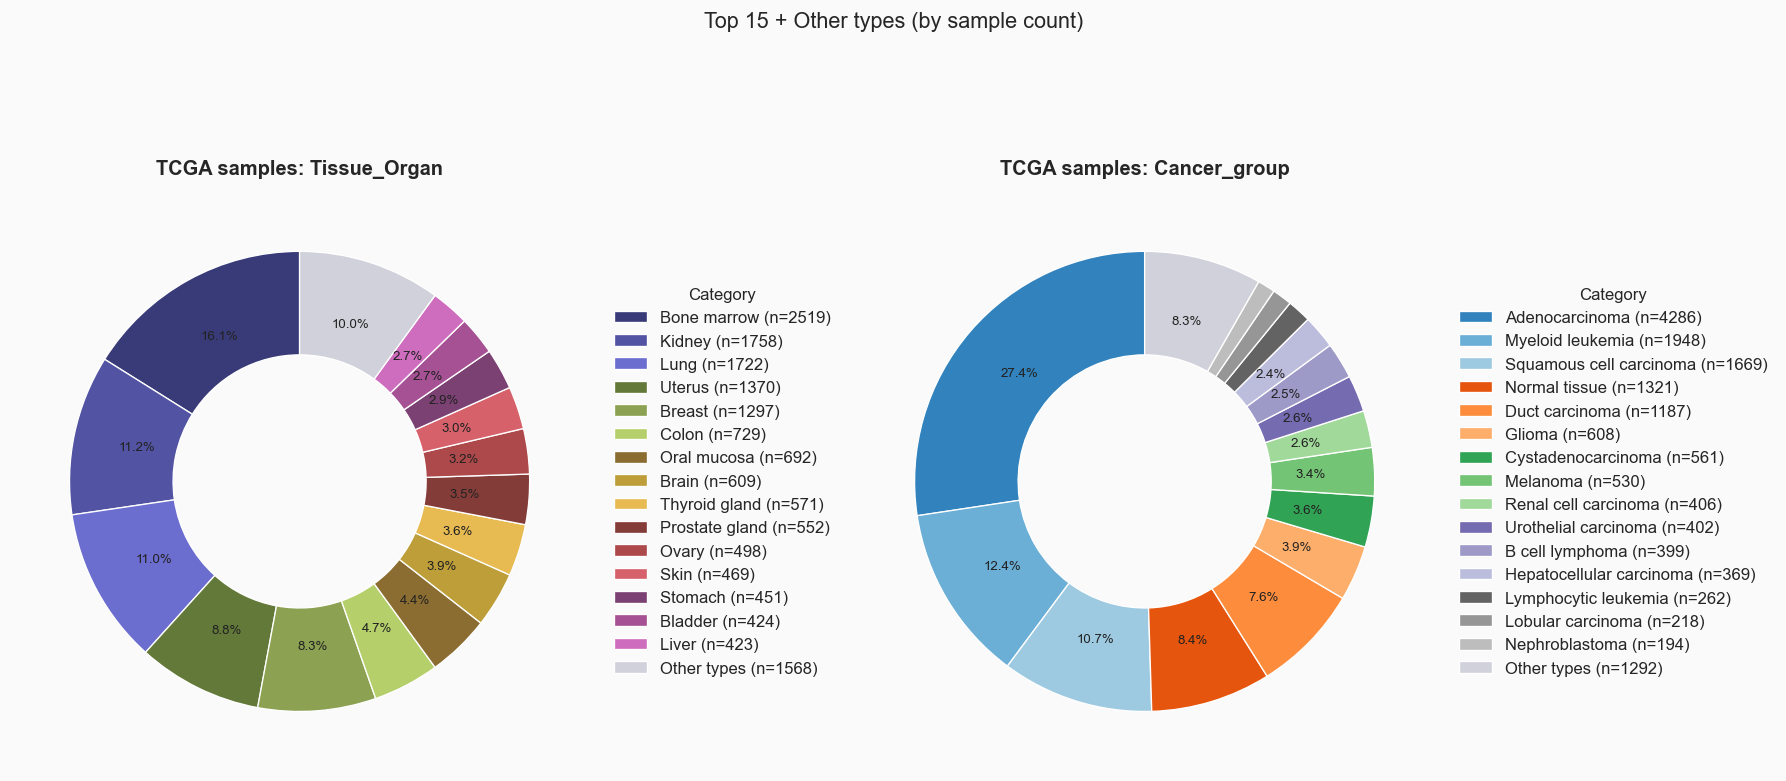

In [164]:
import matplotlib.pyplot as plt
import numpy as np

TOP_N = 15
OTHER = "Other types"
MISSING = "<missing>"


def counts_for_pie(series: pd.Series, top_n: int = TOP_N) -> tuple[list[str], np.ndarray]:
    s = series.fillna(MISSING).astype(str)
    vc = s.value_counts()
    if len(vc) <= top_n:
        return vc.index.tolist(), vc.values.astype(float)
    top = vc.iloc[:top_n]
    rest = vc.iloc[top_n:].sum()
    labels = top.index.tolist() + [OTHER]
    sizes = np.append(top.values.astype(float), float(rest))
    return labels, sizes


def _cmap(name: str):
    try:
        return plt.colormaps[name]
    except (AttributeError, TypeError, KeyError):
        return plt.cm.get_cmap(name)


import matplotlib.pyplot as plt
import pandas as pd

def plot_pie_pair(
    data: pd.DataFrame,
    col_a: str,
    col_b: str,
    title_prefix: str = "Samples",
    save_path: str = None,   # например "pie_charts.pdf"
) -> None:
    
    fig, axes = plt.subplots(1, 2, figsize=(15, 7), dpi=120)
    fig.patch.set_facecolor("#fafafa")

    cmap_a = _cmap("tab20b")
    cmap_b = _cmap("tab20c")

    for ax, col, title, cmap in zip(
        axes,
        (col_a, col_b),
        (f"{title_prefix}: {col_a}", f"{title_prefix}: {col_b}"),
        (cmap_a, cmap_b),
    ):
        if col not in data.columns:
            ax.set_visible(False)
            continue

        labels, sizes = counts_for_pie(data[col], TOP_N)
        n = len(labels)
        colors = [cmap(i / max(n - 1, 1)) for i in range(n)]

        for i, lab in enumerate(labels):
            if lab in (OTHER, MISSING):
                colors[i] = (0.82, 0.82, 0.86, 1.0)

        wedges, texts, autotexts = ax.pie(
            sizes,
            labels=None,
            autopct=lambda p: f"{p:.1f}%" if p >= 2 else "",
            pctdistance=0.72,
            colors=colors,
            wedgeprops=dict(width=0.45, edgecolor="white", linewidth=0.8),
            startangle=90,
        )

        for t in autotexts:
            t.set_fontsize(8)
            t.set_color("#222")

        ax.set_title(title, fontsize=12, fontweight="600", pad=12)

        leg_labels = [f"{lab} (n={int(sz)})" for lab, sz in zip(labels, sizes)]
        ax.legend(
            wedges,
            leg_labels,
            title="Category",
            loc="center left",
            bbox_to_anchor=(1.02, 0.5),
            fontsize=10,
            title_fontsize=10,
            frameon=False,
        )

    plt.suptitle(f"Top {TOP_N} + {OTHER} (by sample count)", fontsize=13, y=1.02)
    plt.tight_layout()

    # Сохранение в PDF
    if save_path:
        plt.savefig(
            save_path,
            format="pdf",
            bbox_inches="tight",
            facecolor=fig.get_facecolor()
        )

    plt.show()

_src = df_vst if "df_vst" in dir() else df
plot_pie_pair(_src, "Tissue_Organ", "Cancer_group", title_prefix="TCGA samples", 
save_path='/Users/neuropromotion/Desktop/miRNA/bulk_review/pipeline_python/figures/tcga_pie.pdf')




# τ (tau) 



In [111]:
import numpy as np

# --- та же схема метаколонок, что и для VST ---
META_COLS = [
    "sample_barcode",
    "Tissue_Organ",
    "Sample Type",
    "Project ID",
    "Cancer_group", 
] 

if len(mir_cols) == 0:
    raise ValueError("Нет колонок miRNA в df_vst — сначала выполните ячейку VST.")

for col in ("Tissue_Organ", "Cancer_group"):
    if col not in df_vst.columns:
        raise ValueError(f"В df_vst нет колонки {col!r}")


def tau_score(x: np.ndarray) -> float:
    """Одна miRNA: вектор медиан по группам (длина G). Как tau_score() в R."""
    x = np.maximum(np.asarray(x, dtype=float), 0.0)
    if x.size < 2:
        return np.nan
    mx = np.nanmax(x)
    if not np.isfinite(mx) or mx <= 0:
        return np.nan
    xn = x / mx
    return float(np.nansum(1.0 - xn) / (x.size - 1))


def median_profile_by_group(df: pd.DataFrame, group_col: str, mir_cols: list[str]) -> pd.DataFrame:
    """Строки = группы, столбцы = mature_name; значения = медиана VST."""
    return df.groupby(group_col, dropna=False)[mir_cols].median()


def tau_per_mirna(med_wide: pd.DataFrame) -> pd.Series:
    """По каждому столбцу (miRNA) считаем τ по строкам (группам)."""
    return med_wide.apply(lambda col: tau_score(col.values), axis=0)



In [112]:
# медианы VST по группам
med_tissue = median_profile_by_group(df_vst, "Tissue_Organ", mir_cols)
med_cancer = median_profile_by_group(df_vst, "Cancer_group", mir_cols)

print("Групп (Tissue_Organ):", med_tissue.shape[0], "| miRNA:", med_tissue.shape[1])
print("Групп (Cancer_group):", med_cancer.shape[0], "| miRNA:", med_cancer.shape[1])


Групп (Tissue_Organ): 29 | miRNA: 2011
Групп (Cancer_group): 34 | miRNA: 2011


In [113]:
tau_tissue = tau_per_mirna(med_tissue)
tau_cancer = tau_per_mirna(med_cancer)

tau_df = (
    pd.DataFrame({"tau_tissue_organ": tau_tissue, "tau_cancer_group": tau_cancer})
    #pd.DataFrame({"tau_cancer_group": tau_cancer})
    .reset_index()
    .rename(columns={"index": "mature_name"})
)

# краткая сводка
display(tau_df.describe())
display(tau_df.head(10))

# при желании: топ по τ
print("Топ 5 по τ (Tissue_Organ):")
display(tau_df.nlargest(5, "tau_tissue_organ")[["mature_name", "tau_tissue_organ"]])
print("Топ 5 по τ (Cancer_group):")
display(tau_df.nlargest(5, "tau_cancer_group")[["mature_name", "tau_cancer_group"]])

,tau_tissue_organ,tau_cancer_group
count,1227.000000,1222.000000
mean,0.719561,0.717092
std,0.296677,0.288258
min,0.056961,0.072848
25%,0.446807,0.462545
50%,0.860984,0.829817
75%,0.987439,0.982775
max,1.000000,1.000000


,mature_name,tau_tissue_organ,tau_cancer_group
0,hsa-let-7a-2-3p,0.386876,0.357379
1,hsa-let-7a-3p,0.172336,0.231600
2,hsa-let-7a-5p,0.086338,0.074560
3,hsa-let-7b-3p,0.320834,0.321718
4,hsa-let-7b-5p,0.158172,0.153265
5,hsa-let-7c-3p,0.388353,0.343961
6,hsa-let-7c-5p,0.213453,0.192623
7,hsa-let-7d-3p,0.288900,0.279963
8,hsa-let-7d-5p,0.288664,0.288760
9,hsa-let-7e-3p,0.446945,0.390814


Топ 5 по τ (Tissue_Organ):


,mature_name,tau_tissue_organ
19,hsa-miR-1-5p,1.0
41,hsa-miR-1181,1.0
50,hsa-miR-1224-3p,1.0
55,hsa-miR-1226-5p,1.0
56,hsa-miR-1227-3p,1.0


Топ 5 по τ (Cancer_group):


,mature_name,tau_cancer_group
19,hsa-miR-1-5p,1.0
40,hsa-miR-1180-5p,1.0
41,hsa-miR-1181,1.0
56,hsa-miR-1227-3p,1.0
61,hsa-miR-122b-3p,1.0


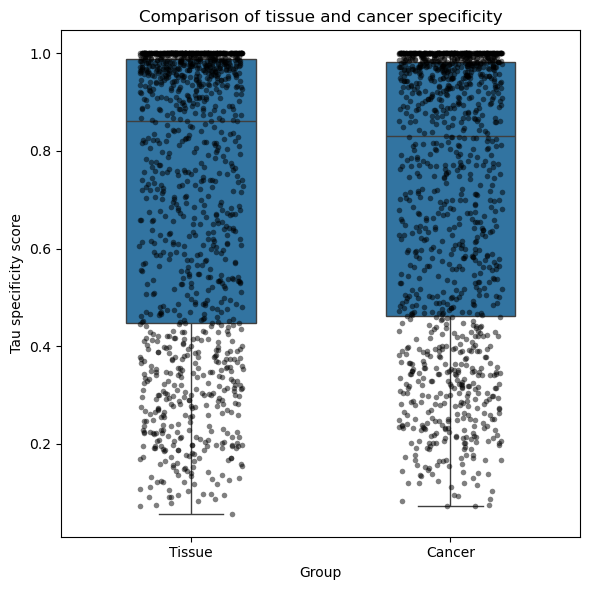

In [114]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

plot_df = pd.DataFrame({
    "Tau": list(tau_tissue.values) + list(tau_cancer.values),
    "Group": (["Tissue"] * len(tau_tissue)) +
            (["Cancer"] * len(tau_cancer)) 
             
})

plt.figure(figsize=(6,6))

sns.boxplot(
    data=plot_df,
    x="Group",
    y="Tau",
    width=0.5
)

sns.stripplot(
    data=plot_df,
    x="Group",
    y="Tau",
    color="black",
    alpha=0.5,
    size=4,
    jitter=0.2
)

plt.ylabel("Tau specificity score")
plt.title("Comparison of tissue and cancer specificity")

plt.tight_layout()
plt.show()

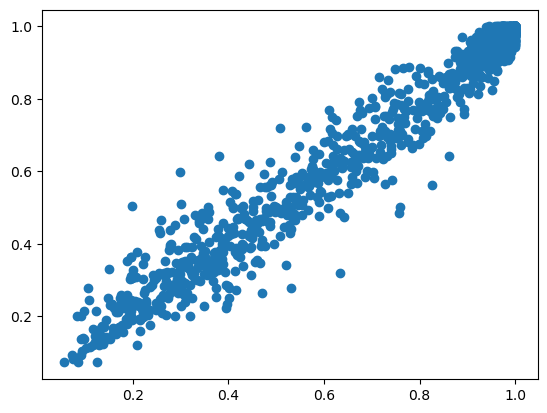

In [115]:
plt.scatter(tau_tissue, tau_cancer)

# DE cancer vs normal (TCGA)

In [118]:
# Метаданные в `meta` (строки = те же образцы, что индекс `df`), в `df` остаются только miRNA.
# Ключ образца — `sample_barcode` (как в merge выше), без лишней колонки `barcode` в counts.

_meta_cols = [
    "Tissue_Organ",
    "Sample Type",
    "Project ID",
    "Cancer_group",
]

if any(c in df.columns for c in _meta_cols):
    missing = [c for c in _meta_cols if c not in df.columns]
    if missing:
        raise KeyError(
            f"В df нет метаколонок {missing}. Сначала wide-merge с метаданными."
        )
    meta = df[_meta_cols].copy()
    meta.insert(0, "sample_barcode", df.index.astype(str))
    df = df.drop(columns=_meta_cols)
elif "meta" not in dir() or not isinstance(meta, pd.DataFrame):
    raise RuntimeError(
        "В df уже нет Tissue_Organ/…, но `meta` не задан. Выполните merge или восстановите meta."
    )

In [119]:
df = df.T
df.head()

sample_barcode,0065bfd9-e1b9-43a8-9379-9658ba,01bf1906-9bdc-41c3-89a0-b89ef6,01d1ffca-4235-4dfe-bf62-56f71d,05387aad-2a1f-42c2-8d6f-950598,0630ecb0-b664-4e75-bb3c-fb62ee,079b5600-6afc-4785-bb22-48cfab,07c4bb93-a373-4748-a2c7-5806cb,08296da7-70ea-44df-8646-09f2cc,09659708-7747-4d59-a3b9-e221e0,0aef1fe8-ca61-4113-81d0-d82ee7,...,f6c215ea-5381-4521-bb61-be8e97,f9d6fb1b-988e-4d28-9272-cc672f,faadb553-9437-42cb-b469-498d67,fbb41c94-aabd-49cc-90b2-882c3e,fc0aa1e4-c1d8-43ed-a5cd-038f61,fd4edc52-09ef-4b01-be7c-f23f05,fe4b3b1c-9f7f-4109-8a76-ca1d6f,fe591474-99d7-44d3-be73-c3b8ed,fe83e13f-9754-403b-8f74-d6caf8,ffc76bfb-61f6-4492-a782-c23321
mature_name,,,,,,,,,,,,,,,,,,,,,
hsa-let-7a-2-3p,2.0,2.0,1.0,11.0,2.0,0.0,0.0,18.0,0.0,0.0,...,8.0,0.0,1.0,8.0,0.0,0.0,0.0,2.0,17.0,1.0
hsa-let-7a-3p,62.0,7.0,100.0,35.0,34.0,15.0,224.0,78.0,8.0,0.0,...,72.0,105.0,35.0,129.0,24.0,14.0,11.0,52.0,183.0,27.0
hsa-let-7a-5p,272328.0,232351.0,131096.0,342363.0,254571.0,216248.0,243651.0,194325.0,63820.0,85796.0,...,532699.0,214399.0,497759.0,178129.0,270062.0,193937.0,349872.0,337899.0,546459.0,177388.0
hsa-let-7b-3p,122.0,61.0,56.0,449.0,155.0,72.0,117.0,157.0,37.0,38.0,...,472.0,100.0,104.0,168.0,67.0,90.0,79.0,177.0,273.0,228.0
hsa-let-7b-5p,34996.0,40806.0,13835.0,141271.0,31025.0,57395.0,41720.0,41212.0,15269.0,17150.0,...,90961.0,34219.0,175231.0,38624.0,101032.0,24204.0,62061.0,177180.0,67362.0,134035.0


In [120]:
import numpy as np

# как в scripts/07_tumor_vs_normal_stn.R
MIN_TUMORS = 10
MIN_NORMALS = 5

NORMAL_SAMPLE_TYPES = {
    "Solid Tissue Normal",
    "Bone Marrow Normal",
    "Lymphoid Normal",
}
TUMOR_SAMPLE_TYPES = {
    "Primary Tumor",
    "Primary Blood Derived Cancer - Bone Marrow",
    "Primary Blood Derived Cancer - Peripheral Blood",
    'Recurrent Blood Derived Cancer - Bone Marrow',
    'Recurrent Blood Derived Cancer - Peripheral Blood',
    'Recurrent Tumor',
}


# Строки = образцы, столбцы = miRNA. Если перед этим был df.T (ячейка выше),
# сейчас df — miRNA × образцы: берём df.T и выравниваем по sample_barcode из meta.
if "meta" in globals() and isinstance(meta, pd.DataFrame) and "sample_barcode" in meta.columns:
    samples = meta["sample_barcode"].astype(str)
    n = len(samples)
    if df.shape[0] == n:
        wide = df
    elif df.shape[1] == n:
        wide = df.T
    else:
        raise ValueError(
            f"В meta {n} образцов, у df shape {df.shape}. "
            "Ожидается samples×miRNA или miRNA×samples."
        )
    wide = wide.reindex(index=samples.values).fillna(0.0)
else:
    wide = df
    samples = wide.index.astype(str)

counts_all = pd.DataFrame(
    np.round(np.maximum(wide.to_numpy(dtype=float), 0)).astype(np.int64),
    index=pd.Index(samples.values.astype(str), name="sample_barcode"),
    columns=wide.columns.astype(str),
)

meta_de = pd.read_parquet(PATH_META)


def map_condition(sample_type) -> str | None:
    if pd.isna(sample_type):
        return None
    st = str(sample_type)
    if st in NORMAL_SAMPLE_TYPES:
        return "normal"
    if st in TUMOR_SAMPLE_TYPES:
        return "tumor"
    return None


meta_de = meta_de.copy()
meta_de["sample_barcode"] = meta_de["sample_barcode"].astype(str)
meta_de["condition"] = meta_de["Sample Type"].map(map_condition)
meta_de = meta_de.dropna(subset=["condition"])
meta_de = meta_de[meta_de["sample_barcode"].isin(counts_all.index)]

if "Project ID" not in meta_de.columns:
    raise ValueError("В метаданных нет колонки 'Project ID'")

proj_tab = (
    meta_de.groupby(["Project ID", "condition"], observed=False)
    .size()
    .unstack(fill_value=0)
)
for c in ("normal", "tumor"):
    if c not in proj_tab.columns:
        proj_tab[c] = 0

eligible_projects = proj_tab[
    (proj_tab["tumor"] >= MIN_TUMORS) & (proj_tab["normal"] >= MIN_NORMALS)
].index.tolist()

print(f"Проектов с ≥{MIN_TUMORS} tumor и ≥{MIN_NORMALS} normal:", len(eligible_projects))
display(proj_tab.loc[eligible_projects].sort_values("tumor", ascending=False))



Проектов с ≥10 tumor и ≥5 normal: 21


condition,normal,tumor
Project ID,,
TARGET-AML,62,1771
TCGA-BRCA,104,1087
CPTAC-3,603,1062
TCGA-UCEC,33,540
TCGA-KIRC,71,519
TCGA-LUAD,20,515
TCGA-HNSC,44,515
TCGA-THCA,59,504
TCGA-PRAD,52,497


In [ ]:
expample_1 = meta[meta['Project ID'] == eligible_projects[1]]
expample_1_normal = expample_1[expample_1['Sample Type'].isin(NORMAL_SAMPLE_TYPES)]
expample_1_tumor = expample_1[expample_1['Sample Type'].isin(TUMOR_SAMPLE_TYPES)]

normal_samples = expample_1_normal['sample_barcode'].tolist()
tumor_samples = expample_1_tumor['sample_barcode'].tolist()

tumor_df = df[tumor_samples]
normal_df = df[normal_samples]


### DESeq2 (PyDESeq2) cancer vs normal


In [122]:
# TCGA ∩ GTEx: заново собираем список общих mature_name и сохраняем в отдельную папку.
PATH_GTEX_COUNTS = PROC / "gtex_mature_counts_filtered.parquet"
if not PATH_COUNTS.is_file():
    raise FileNotFoundError(PATH_COUNTS)
if not PATH_GTEX_COUNTS.is_file():
    raise FileNotFoundError(PATH_GTEX_COUNTS)

PANEL_DIR = PROJ_ROOT / "pipeline_python" / "tcga_gtex_shared_panel"
PANEL_DIR.mkdir(parents=True, exist_ok=True)

tcga_mir = pd.read_parquet(PATH_COUNTS, columns=["mature_name"])["mature_name"].astype(str)
gtex_mir = pd.read_parquet(PATH_GTEX_COUNTS, columns=["mature_name"])["mature_name"].astype(str)

tcga_u = set(tcga_mir)
gtex_u = set(gtex_mir)

# порядок как в TCGA parquet (стабильно и совпадает с «первым встретившимся» в long-таблице)
shared_miRs: list[str] = []
seen: set[str] = set()
for m in tcga_mir:
    if m in gtex_u and m not in seen:
        seen.add(m)
        shared_miRs.append(m)

out_tsv = PANEL_DIR / "shared_mature_mirna.tsv"
out_txt = PANEL_DIR / "shared_mature_mirna.txt"
pd.DataFrame({"mature_name": shared_miRs}).to_csv(out_tsv, sep="\t", index=False)
out_txt.write_text("\n".join(shared_miRs) + ("\n" if shared_miRs else ""))

import json

summary = {
    "n_tcga_unique": len(tcga_u),
    "n_gtex_unique": len(gtex_u),
    "n_shared": len(shared_miRs),
    "path_tcga": str(PATH_COUNTS.resolve()),
    "path_gtex": str(PATH_GTEX_COUNTS.resolve()),
}
(PANEL_DIR / "intersection_summary.json").write_text(
    json.dumps(summary, indent=2), encoding="utf-8"
)

print(
    f"TCGA unique: {len(tcga_u)} | GTEx unique: {len(gtex_u)} | shared: {len(shared_miRs)}"
)
print("записано:", out_tsv)

# Если df уже wide (строки = образцы, столбцы = miRNA), перед DE можно сузить панель:
# keep = [c for c in shared_miRs if c in df.columns]
# df = df[keep]


TCGA unique: 2011 | GTEx unique: 622 | shared: 604
записано: /Users/neuropromotion/Desktop/miRNA/bulk_review/pipeline_python/tcga_gtex_shared_panel/shared_mature_mirna.tsv


In [ ]:
from pydeseq2.dds import DeseqDataSet
from pydeseq2.ds import DeseqStats
from pydeseq2.default_inference import DefaultInference

de_parts: list[pd.DataFrame] = []

for project_id in eligible_projects:
    m = meta[meta["Project ID"] == project_id].copy()
    m["sample_barcode"] = m["sample_barcode"].astype(str)
    m = m[m["sample_barcode"].isin(counts_all.index)]

    m_normal = m[m["Sample Type"].isin(NORMAL_SAMPLE_TYPES)]
    m_tumor = m[m["Sample Type"].isin(TUMOR_SAMPLE_TYPES)]

    ids_normal = m_normal["sample_barcode"].drop_duplicates().tolist()
    ids_tumor = m_tumor["sample_barcode"].drop_duplicates().tolist()

    if not ids_normal or not ids_tumor:
        print(project_id, "— нет normal или tumor среди образцов в counts_all, пропуск")
        continue

    # порядок строк: сначала normal (базовый уровень фактора), потом tumor
    sample_order = ids_normal + ids_tumor
    counts_sub = counts_all.loc[sample_order]

    meta_f = pd.DataFrame(
        {
            "condition": ["normal"] * len(ids_normal) + ["tumor"] * len(ids_tumor),
        },
        index=sample_order,
    )
    meta_f["condition"] = pd.Categorical(
        meta_f["condition"], categories=["normal", "tumor"]
    )

    # miRNA оставляем, если в ≥3 образцах count ≥ 5 (как в R-скрипте)
    mat = counts_sub.to_numpy().T
    keep = (mat >= 5).sum(axis=1) >= 3
    counts_f = counts_sub.loc[:, counts_sub.columns[keep]]

    try:
        dds = DeseqDataSet(
            counts=counts_f,
            metadata=meta_f,
            design="~condition",
            refit_cooks=True,
            quiet=True,
        )
        dds.deseq2()
        stat = DeseqStats(
            dds,
            contrast=["condition", "tumor", "normal"],
            inference=DefaultInference(n_cpus=1),
            quiet=True,
        )
        stat.summary()
    except Exception as ex:
        print(project_id, "— PyDESeq2:", ex)
        continue

    res = stat.results_df.reset_index()
    if res.columns[0] != "mature_name":
        res = res.rename(columns={res.columns[0]: "mature_name"})

    res["project_id"] = project_id
    res["n_normal"] = len(ids_normal)
    res["n_tumor"] = len(ids_tumor)
    de_parts.append(res)
    print(
        project_id,
        "— OK, normal:",
        len(ids_normal),
        "tumor:",
        len(ids_tumor),
        "miRNA после фильтра:",
        counts_f.shape[1],
    )

if not de_parts:
    raise RuntimeError("Нет ни одного успешного DE — проверьте meta, counts_all, eligible_projects.")

de_all = pd.concat(de_parts, ignore_index=True)
print("строк в de_all:", len(de_all), "| проектов:", de_all["project_id"].nunique())
de_all.head()


CGCI-BLGSP — OK, normal: 10 tumor: 237 miRNA после фильтра: 464
CPTAC-3 — OK, normal: 603 tumor: 1062 miRNA после фильтра: 596
TARGET-AML — OK, normal: 62 tumor: 1771 miRNA после фильтра: 502
TARGET-RT — OK, normal: 6 tumor: 63 miRNA после фильтра: 497
TARGET-WT — OK, normal: 6 tumor: 128 miRNA после фильтра: 451
TCGA-BLCA — OK, normal: 19 tumor: 406 miRNA после фильтра: 511
TCGA-BRCA — OK, normal: 104 tumor: 1087 miRNA после фильтра: 500
TCGA-CHOL — OK, normal: 9 tumor: 35 miRNA после фильтра: 394
TCGA-COAD — OK, normal: 8 tumor: 451 miRNA после фильтра: 452
TCGA-ESCA — OK, normal: 13 tumor: 183 miRNA после фильтра: 457
TCGA-HNSC — OK, normal: 44 tumor: 515 miRNA после фильтра: 497
TCGA-KICH — OK, normal: 25 tumor: 66 miRNA после фильтра: 415
TCGA-KIRC — OK, normal: 71 tumor: 519 miRNA после фильтра: 435
TCGA-KIRP — OK, normal: 32 tumor: 290 miRNA после фильтра: 463
TCGA-LIHC — OK, normal: 50 tumor: 370 miRNA после фильтра: 502
TCGA-LUAD — OK, normal: 20 tumor: 515 miRNA после фильтра

,mature_name,baseMean,log2FoldChange,lfcSE,stat,pvalue,padj,project_id,n_normal,n_tumor
0,hsa-let-7a-2-3p,7.292158,3.734945,0.763804,4.889923,1.008756e-06,3.805387e-06,CGCI-BLGSP,10,237
1,hsa-let-7a-3p,64.242439,0.615312,0.329535,1.867211,6.187216e-02,1.021661e-01,CGCI-BLGSP,10,237
2,hsa-let-7b-5p,13990.087310,1.886136,0.340133,5.545298,2.934540e-08,1.249199e-07,CGCI-BLGSP,10,237
3,hsa-let-7c-3p,8.151226,4.751393,0.891239,5.331223,9.755368e-08,4.041510e-07,CGCI-BLGSP,10,237
4,hsa-let-7d-5p,824.311833,-0.671737,0.217652,-3.086284,2.026751e-03,4.565109e-03,CGCI-BLGSP,10,237


In [127]:
de_all['abs_log2FoldChange'] = de_all['log2FoldChange'].abs()
de_all

,mature_name,baseMean,log2FoldChange,lfcSE,stat,pvalue,padj,project_id,n_normal,n_tumor,abs_log2FoldChange
0,hsa-let-7a-2-3p,7.292158,3.734945,0.763804,4.889923,1.008756e-06,3.805387e-06,CGCI-BLGSP,10,237,3.734945
1,hsa-let-7a-3p,64.242439,0.615312,0.329535,1.867211,6.187216e-02,1.021661e-01,CGCI-BLGSP,10,237,0.615312
2,hsa-let-7b-5p,13990.087310,1.886136,0.340133,5.545298,2.934540e-08,1.249199e-07,CGCI-BLGSP,10,237,1.886136
3,hsa-let-7c-3p,8.151226,4.751393,0.891239,5.331223,9.755368e-08,4.041510e-07,CGCI-BLGSP,10,237,4.751393
4,hsa-let-7d-5p,824.311833,-0.671737,0.217652,-3.086284,2.026751e-03,4.565109e-03,CGCI-BLGSP,10,237,0.671737
...,...,...,...,...,...,...,...,...,...,...,...
10076,hsa-miR-96-5p,198.094688,4.467487,0.195201,22.886555,6.324472e-116,3.320348e-113,TCGA-UCEC,33,540,4.467487
10077,hsa-miR-98-5p,242.620682,0.129874,0.116210,1.117578,2.637471e-01,3.205260e-01,TCGA-UCEC,33,540,0.129874
10078,hsa-miR-99a-5p,4167.995346,-2.942224,0.235576,-12.489481,8.520776e-36,1.278116e-34,TCGA-UCEC,33,540,2.942224
10079,hsa-miR-99b-3p,469.870018,1.032249,0.200661,5.144231,2.686192e-07,7.086689e-07,TCGA-UCEC,33,540,1.032249


In [182]:
#de_all.to_csv('/Users/neuropromotion/Desktop/miRNA/bulk_review/pipeline_python/tcga_gtex_shared_panel/de_all.csv', index=False)
de_all = pd.read_csv('/Users/neuropromotion/Desktop/miRNA/bulk_review/pipeline_python/tcga_gtex_shared_panel/de_all.csv')
de_all.head()

,mature_name,baseMean,log2FoldChange,lfcSE,stat,pvalue,padj,project_id,n_normal,n_tumor,abs_log2FoldChange
0,hsa-let-7a-2-3p,7.292158,3.734945,0.763804,4.889923,1.008756e-06,3.805387e-06,CGCI-BLGSP,10,237,3.734945
1,hsa-let-7a-3p,64.242439,0.615312,0.329535,1.867211,6.187216e-02,1.021661e-01,CGCI-BLGSP,10,237,0.615312
2,hsa-let-7b-5p,13990.087310,1.886136,0.340133,5.545298,2.934540e-08,1.249199e-07,CGCI-BLGSP,10,237,1.886136
3,hsa-let-7c-3p,8.151226,4.751393,0.891239,5.331223,9.755368e-08,4.041510e-07,CGCI-BLGSP,10,237,4.751393
4,hsa-let-7d-5p,824.311833,-0.671737,0.217652,-3.086284,2.026751e-03,4.565109e-03,CGCI-BLGSP,10,237,0.671737


In [190]:
import pandas as pd

with pd.ExcelWriter(
    "/Users/neuropromotion/Desktop/miRNA/bulk_review/pipeline_python/tcga_gtex_shared_panel/de_all.xlsx",
    engine="openpyxl"
) as writer:

    de_all.to_excel(writer, sheet_name="DE_results", index=False)

    description = pd.DataFrame({
        "column": [
            "mature_name", "baseMean", "log2FoldChange", "lfcSE",
            "stat", "pvalue", "padj", "project_id",
            "n_normal", "n_tumor"
        ],
        "description": [
            "Mature miRNA identifier",
            "Mean normalized counts across all samples in a project",
            "Log2 fold change (tumor vs normal)",
            "Standard error of log2 fold change",
            "Wald test statistic",
            "Nominal p-value for differential expression",
            "FDR-adjusted p-value (Benjamini–Hochberg)",
            "Project identifier",
            "Number of normal samples",
            "Number of tumor samples"
        ]
    })

    description.to_excel(writer, sheet_name="column_descriptions", index=False)

In [157]:
df133 = de_all[de_all['mature_name'] == 'hsa-miR-133b']
df133 = df133[df133['padj'] < 0.01]
df133[df133['log2FoldChange'] > 1]

,mature_name,baseMean,log2FoldChange,lfcSE,stat,pvalue,padj,project_id,n_normal,n_tumor,abs_log2FoldChange
63,hsa-miR-133b,6.221775,4.577433,1.549702,2.953750,3.139380e-03,0.006839,CGCI-BLGSP,10,237,4.577433
1129,hsa-miR-133b,3.130243,2.109388,0.414831,5.084937,3.677476e-07,0.000001,TARGET-AML,62,1771,2.109388
2125,hsa-miR-133b,72.361935,4.570413,1.507461,3.031861,2.430514e-03,0.006418,TARGET-WT,6,128,4.570413


In [163]:
meta[meta['Project ID'] == 'TARGET-WT']

mature_name,sample_barcode,Tissue_Organ,Sample Type,Project ID,Cancer_group
sample_barcode,,,,,
TARGET-50-CAAAAB-01A,TARGET-50-CAAAAB-01A,Kidney,Primary Tumor,TARGET-WT,Nephroblastoma
TARGET-50-CAAAAC-01A,TARGET-50-CAAAAC-01A,Kidney,Primary Tumor,TARGET-WT,Nephroblastoma
TARGET-50-CAAAAH-01A,TARGET-50-CAAAAH-01A,Kidney,Primary Tumor,TARGET-WT,Nephroblastoma
TARGET-50-CAAAAJ-01A,TARGET-50-CAAAAJ-01A,Kidney,Primary Tumor,TARGET-WT,Nephroblastoma
TARGET-50-CAAAAL-01A,TARGET-50-CAAAAL-01A,Kidney,Primary Tumor,TARGET-WT,Nephroblastoma
...,...,...,...,...,...
TARGET-50-PALJIP-02A,TARGET-50-PALJIP-02A,Kidney,Recurrent Tumor,TARGET-WT,Nephroblastoma
TARGET-50-PALKCW-01A,TARGET-50-PALKCW-01A,Kidney,Primary Tumor,TARGET-WT,Nephroblastoma
TARGET-50-PALKCW-11A,TARGET-50-PALKCW-11A,Kidney,Solid Tissue Normal,TARGET-WT,Normal tissue


In [129]:
# Сводка по панели shared_miRs: в скольких проектах miRNA значимо (padj) и с |log2FC|>1
# в сторону опухоли (up: log2FC > 1) или в сторону нормали (down: log2FC < -1).
# Контраст в de_all: tumor vs normal → положительный LFC = выше в tumor.
# median_log2fc / median_padj — по всем когортам с padj < PADJ_THR (одна строка DE = один проект).

PADJ_THR = 0.01
LFC_THR = 1.0

from scipy.stats import binomtest


def directional_binom_pvalues(n_up: int, n_down: int) -> tuple[float, float, float]:
    """
    Binomial test for imbalance between UP and DOWN cohort counts (one miRNA).

    **Scope (must match the counters in this notebook).** Only *directional* cohorts
    enter the denominator: trials = n_up + n_down, where a cohort is counted as UP
    if it passes padj and log2FC > LFC_THR, and as DOWN if it passes padj and
    log2FC < -LFC_THR. Cohorts that are not significant under padj, or significant
    but with |log2FC| ≤ LFC_THR, are excluded from both n_up and n_down (they are
    not “directional” for this rule set).

    **Model.** Under H0, conditional on being directional, each cohort is as likely
    to be UP as DOWN: Binomial(n_up + n_down, 0.5) with observed successes k = n_up.

    **Returns** (floats; all NaN if n_up + n_down == 0)
    - p_two_sided: `binomtest(k, n, p=0.5, alternative="two-sided").pvalue`
    - p_excess_up: one-sided p for *more* UP than expected (`alternative="greater"` on k)
    - p_excess_down: one-sided p for *fewer* UP than expected (`alternative="less"` on k),
      i.e. enrichment of DOWN relative to a 50/50 split.

    This matches the convention used in `build_03_validation_de_mirna_n_cohorts_tau.py`
    (binom_p_two_sided, binom_p_up, binom_p_down).
    """
    n = int(n_up) + int(n_down)
    if n == 0:
        return (float("nan"), float("nan"), float("nan"))
    k = int(n_up)
    p2 = float(binomtest(k, n, p=0.5, alternative="two-sided").pvalue)
    p_up = float(binomtest(k, n, p=0.5, alternative="greater").pvalue)
    p_dn = float(binomtest(k, n, p=0.5, alternative="less").pvalue)
    return (p2, p_up, p_dn)


rows: list[dict] = []
for mir in shared_miRs:
    sub = de_all.loc[de_all["mature_name"] == mir, ["project_id", "log2FoldChange", "padj"]].copy()
    sub["padj"] = pd.to_numeric(sub["padj"], errors="coerce")
    sub["log2FoldChange"] = pd.to_numeric(sub["log2FoldChange"], errors="coerce")

    sig = sub[sub["padj"] < PADJ_THR]
    # уникальные проекты (не число строк в de_all)
    up_proj = sig.loc[sig["log2FoldChange"] > LFC_THR, "project_id"].drop_duplicates()
    down_proj = sig.loc[sig["log2FoldChange"] < -LFC_THR, "project_id"].drop_duplicates()

    # медианы по всем значимым когортам (padj < PADJ_THR); если нет — NaN
    if sig.empty:
        med_lfc = float("nan")
        med_padj = float("nan")
    else:
        med_lfc = float(sig["log2FoldChange"].median())
        med_padj = float(sig["padj"].median())

    nu = int(up_proj.nunique())
    nd = int(down_proj.nunique())
    p2, p_excess_up, p_excess_down = directional_binom_pvalues(nu, nd)

    rows.append(
        {
            "mature_name": mir,
            "n_projects_up": nu,
            "n_projects_down": nd,
            "median_log2fc": med_lfc,
            "median_padj": med_padj,
            "binom_p_two_sided": p2,
            "binom_p_up": p_excess_up,
            "binom_p_down": p_excess_down,
        }
    )

result = pd.DataFrame(rows)
result



,mature_name,n_projects_up,n_projects_down,median_log2fc,median_padj,binom_p_two_sided,binom_p_up,binom_p_down
0,hsa-let-7a-2-3p,3,1,-0.544267,9.617252e-04,0.625000,0.312500,0.937500
1,hsa-let-7a-3p,1,0,-0.022187,2.011985e-05,1.000000,0.500000,1.000000
2,hsa-let-7b-5p,2,2,-0.381554,8.303934e-07,1.000000,0.687500,0.687500
3,hsa-let-7c-3p,4,6,-0.454561,7.149929e-06,0.753906,0.828125,0.376953
4,hsa-let-7d-5p,0,0,0.294442,3.498912e-04,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...
599,hsa-miR-96-5p,17,0,2.852031,3.827372e-28,0.000015,0.000008,1.000000
600,hsa-miR-98-5p,1,0,0.374089,3.377355e-05,1.000000,0.500000,1.000000
601,hsa-miR-99a-5p,3,7,-0.798077,5.264642e-09,0.343750,0.945312,0.171875
602,hsa-miR-99b-3p,5,1,0.755762,2.006146e-08,0.218750,0.109375,0.984375


In [130]:
result[result['binom_p_down'] < 0.01]

,mature_name,n_projects_up,n_projects_down,median_log2fc,median_padj,binom_p_two_sided,binom_p_up,binom_p_down
80,hsa-miR-133b,3,14,-2.212578,2.248655e-13,0.012726,0.998825,0.006363
93,hsa-miR-139-3p,1,16,-2.501329,2.356733e-24,0.000275,0.999992,0.000137
94,hsa-miR-140-3p,0,8,-1.181627,7.313206e-22,0.007812,1.000000,0.003906
99,hsa-miR-143-3p,2,13,-1.385788,5.338020e-16,0.007385,0.999512,0.003693
103,hsa-miR-145-3p,1,14,-1.596556,7.283341e-19,0.000977,0.999969,0.000488
104,hsa-miR-145-5p,1,14,-1.826211,1.627149e-18,0.000977,0.999969,0.000488
246,hsa-miR-29c-3p,1,10,-1.302692,3.264391e-13,0.011719,0.999512,0.005859
256,hsa-miR-30a-3p,0,12,-1.626820,4.118506e-16,0.000488,1.000000,0.000244
257,hsa-miR-30a-5p,1,10,-1.418178,1.352720e-11,0.011719,0.999512,0.005859
261,hsa-miR-30c-2-3p,1,11,-1.684017,1.121098e-13,0.006348,0.999756,0.003174


In [131]:
result.to_csv('/Users/neuropromotion/Desktop/miRNA/bulk_review/pipeline_python/tcga_gtex_shared_panel/de_binom.csv', index=False)

# Volcano


In [176]:
eligible_projects

['CGCI-BLGSP',
 'CPTAC-3',
 'TARGET-AML',
 'TARGET-RT',
 'TARGET-WT',
 'TCGA-BLCA',
 'TCGA-BRCA',
 'TCGA-CHOL',
 'TCGA-COAD',
 'TCGA-ESCA',
 'TCGA-HNSC',
 'TCGA-KICH',
 'TCGA-KIRC',
 'TCGA-KIRP',
 'TCGA-LIHC',
 'TCGA-LUAD',
 'TCGA-LUSC',
 'TCGA-PRAD',
 'TCGA-STAD',
 'TCGA-THCA',
 'TCGA-UCEC']

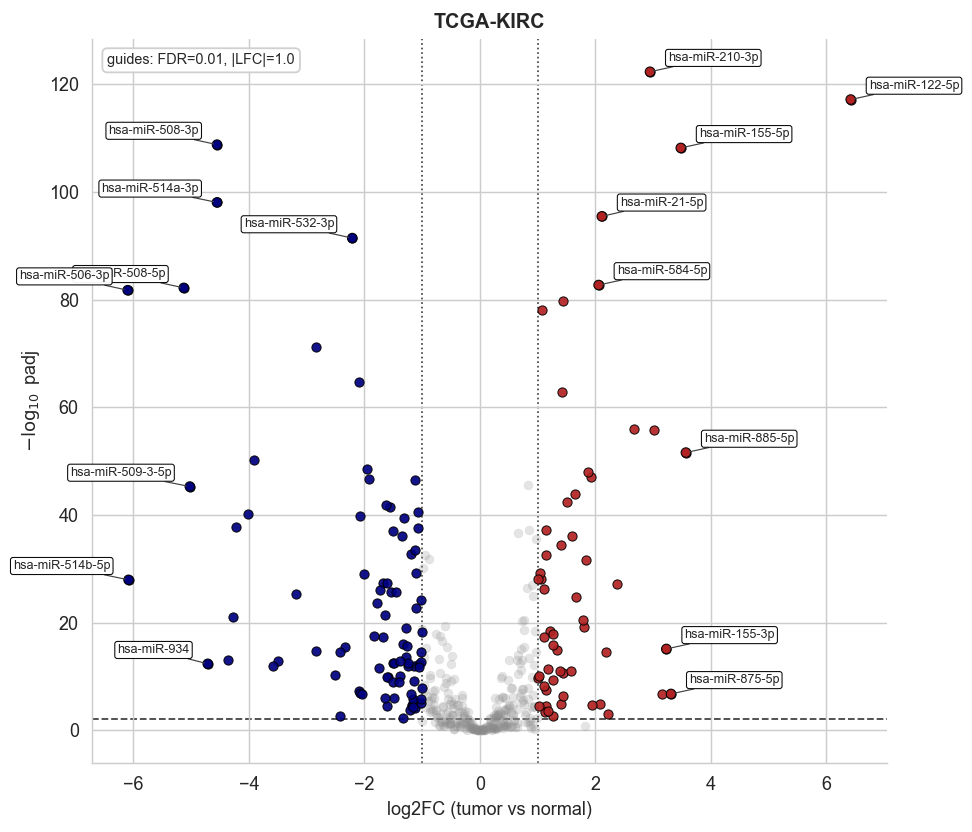

In [179]:
import numpy as np
import matplotlib.pyplot as plt

PADJ_MAX = 0.01
ABS_LFC_MIN = 1.0

# Подстройка превью: смените индекс или имя проекта
VOLCANO_PROJECT = 'TCGA-KIRC'


def plot_volcano(
    res_proj: pd.DataFrame,
    ax,
    title: str,
    *,
    padj_max: float = PADJ_MAX,
    abs_lfc_min: float = ABS_LFC_MIN,
    label_top_padj: int = 0,
    label_top_abs_lfc: int = 0,
) -> None:
    """Volcano: up=firebrick, down=navy, faint gray between thresholds; labels optional."""
    r = res_proj.copy()
    r["padj"] = pd.to_numeric(r["padj"], errors="coerce")
    r["log2FoldChange"] = pd.to_numeric(r["log2FoldChange"], errors="coerce")
    padj = np.clip(r["padj"].to_numpy(dtype=float), 1e-300, None)
    r["neglog10padj"] = -np.log10(padj)
    lfc = r["log2FoldChange"]

    ok = r["padj"].notna() & lfc.notna() & r["neglog10padj"].notna()
    hi = ok & (r["padj"] < padj_max)
    up = hi & (lfc > abs_lfc_min)
    dn = hi & (lfc < -abs_lfc_min)
    between = ok & ~up & ~dn

    ax.set_facecolor("white")
    ax.figure.patch.set_facecolor("white")

    if between.any():
        ax.scatter(
            r.loc[between, "log2FoldChange"],
            r.loc[between, "neglog10padj"],
            s=24,
            alpha=0.22,
            c="#888888",
            edgecolors="#aaaaaa",
            linewidths=0.35,
            rasterized=True,
            zorder=1,
        )
    if dn.any():
        ax.scatter(
            r.loc[dn, "log2FoldChange"],
            r.loc[dn, "neglog10padj"],
            s=26,
            alpha=0.92,
            c="navy",
            edgecolors="black",
            linewidths=0.55,
            rasterized=True,
            zorder=3,
        )
    if up.any():
        ax.scatter(
            r.loc[up, "log2FoldChange"],
            r.loc[up, "neglog10padj"],
            s=26,
            alpha=0.92,
            c="firebrick",
            edgecolors="black",
            linewidths=0.55,
            rasterized=True,
            zorder=3,
        )

    y_thr = -np.log10(padj_max)
    ax.axhline(y_thr, color="#444444", linestyle="--", linewidth=1.0, zorder=0)
    ax.axvline(abs_lfc_min, color="#444444", linestyle=":", linewidth=0.95, zorder=0)
    ax.axvline(-abs_lfc_min, color="#444444", linestyle=":", linewidth=0.95, zorder=0)

    ax.text(
        0.02,
        0.98,
        f"guides: FDR={padj_max}, |LFC|={abs_lfc_min}",
        transform=ax.transAxes,
        fontsize=8,
        verticalalignment="top",
        bbox=dict(boxstyle="round,pad=0.35", facecolor="white", edgecolor="#cccccc", alpha=0.92),
    )

    if "mature_name" in r.columns and (label_top_padj > 0 or label_top_abs_lfc > 0):
        r_ok = r.loc[ok].dropna(subset=["mature_name"])
        if not r_ok.empty:
            chunks = []
            r_up = r_ok[r_ok["log2FoldChange"] >= 0]
            r_dn = r_ok[r_ok["log2FoldChange"] < 0]

            if label_top_padj > 0:
                if not r_up.empty:
                    chunks.append(r_up.nsmallest(label_top_padj, "padj"))
                if not r_dn.empty:
                    chunks.append(r_dn.nsmallest(label_top_padj, "padj"))

            if label_top_abs_lfc > 0:
                if not r_up.empty:
                    chunks.append(
                        r_up.assign(abs_lfc=r_up["log2FoldChange"].abs()).nlargest(
                            label_top_abs_lfc, "abs_lfc"
                        )
                    )
                if not r_dn.empty:
                    chunks.append(
                        r_dn.assign(abs_lfc=r_dn["log2FoldChange"].abs()).nlargest(
                            label_top_abs_lfc, "abs_lfc"
                        )
                    )

            to_label = pd.concat(chunks).drop_duplicates(subset=["mature_name"])

            xs, ys, cols = [], [], []
            for _, row in to_label.iterrows():
                x = float(row["log2FoldChange"])
                y = float(row["neglog10padj"])
                pj = row["padj"]
                xs.append(x)
                ys.append(y)
                if pd.notna(pj) and pj < padj_max and x > abs_lfc_min:
                    cols.append("firebrick")
                elif pd.notna(pj) and pj < padj_max and x < -abs_lfc_min:
                    cols.append("navy")
                else:
                    cols.append("#555555")
            ax.scatter(
                xs,
                ys,
                s=28,
                c=cols,
                edgecolors="black",
                linewidths=0.6,
                alpha=0.95,
                zorder=6,
                rasterized=True,
            )

            for _, row in to_label.iterrows():
                x, y = float(row["log2FoldChange"]), float(row["neglog10padj"])
                if x < 0:
                    xytext, ha = (-10, 6), "right"
                else:
                    xytext, ha = (10, 6), "left"
                ax.annotate(
                    str(row["mature_name"]),
                    xy=(x, y),
                    xytext=xytext,
                    textcoords="offset points",
                    fontsize=7,
                    ha=ha,
                    arrowprops=dict(arrowstyle="-", color="0.25", lw=0.65, shrinkA=0, shrinkB=2),
                    bbox=dict(boxstyle="round,pad=0.2", fc="white", ec="black", alpha=0.95, linewidth=0.6),
                    zorder=7,
                )

    ax.set_xlabel("log2FC (tumor vs normal)", fontsize=10)
    ax.set_ylabel(r"$-\log_{10}$ padj", fontsize=10)
    ax.set_title(title, fontsize=11, fontweight="600")
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)


# --- превью одного проекта (подстройка внешнего вида) ---
_one = de_all[de_all["project_id"] == VOLCANO_PROJECT].copy()
fig, ax = plt.subplots(figsize=(7.6, 6.5), dpi=130)
plot_volcano(
    _one,
    ax,
    str(VOLCANO_PROJECT),
    label_top_padj=5,
    label_top_abs_lfc=5,
)
plt.savefig(
            '/Users/neuropromotion/Desktop/miRNA/bulk_review/pipeline_python/figures/volcano_1.pdf',
            bbox_inches="tight",
            format="pdf"
        )
plt.tight_layout()
plt.show()


In [133]:
# Экспорт volcano по всем eligible-проектам в один PDF (отдельная ячейка)
from matplotlib.backends.backend_pdf import PdfPages

VOLCANO_PDF_DIR = PROJ_ROOT / "pipeline_python" / "figures"
VOLCANO_PDF_DIR.mkdir(parents=True, exist_ok=True)
VOLCANO_PDF_PATH = VOLCANO_PDF_DIR / "volcano_tumor_vs_normal_by_project.pdf"

with PdfPages(VOLCANO_PDF_PATH) as pdf:
    for proj in eligible_projects:
        sub = de_all[de_all["project_id"] == proj]
        if sub.empty:
            continue
        fig, ax = plt.subplots(figsize=(7.6, 6.5), dpi=130)
        plot_volcano(
            sub,
            ax,
            str(proj),
            label_top_padj=5,
            label_top_abs_lfc=5,
        )
        plt.tight_layout()
        pdf.savefig(fig, bbox_inches="tight")
        plt.close(fig)

print("PDF:", VOLCANO_PDF_PATH.resolve())


PDF: /Users/neuropromotion/Desktop/miRNA/bulk_review/pipeline_python/figures/volcano_tumor_vs_normal_by_project.pdf


## LogFC HEATMAP

In [289]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.colors import LinearSegmentedColormap


###########################################
# custom DE colormap
###########################################
neutral_cutoff = 0.25
vmax = 20

w = neutral_cutoff / vmax

colors = [
    (0.00, "#08306B"),
    (0.22, "#4292C6"),

    (0.5 - w, "white"), #f2e8d5
    (0.5 + w, "white"), #f2e8d5

    (0.80, "#FC9272"),
    (1.00, "#99000D")
]

custom_cmap = LinearSegmentedColormap.from_list(
    "de_map",
    colors
)


def plot_pan_cancer_clustermap(
    fc_mat,
    row_colors,
    save_pdf=None
):

    vmax = max(
        3,
        np.nanpercentile(
            np.abs(fc_mat.values),
            98
        )
    )

    # fixed scale centered so
    # -1..1 becomes beige plateau
    vmin = -vmax


    cg = sns.clustermap(
        fc_mat,

        cmap=custom_cmap,

        vmin=vmin,
        vmax=vmax,

        row_cluster=False,
        col_cluster=True,

        metric="correlation",
        method="average",

        row_colors=row_colors,

        figsize=(12,14),

        linewidths=.25,
        linecolor="black",

        xticklabels=True,
        yticklabels=True,

        dendrogram_ratio=(.1,.12),

        cbar_pos=(
            .02,.82,.03,.12
        ),

        cbar_kws={
            "label":"log2FC tumor vs normal"
        }
    )


    ##################################
    # labels
    ##################################

    cg.ax_heatmap.set_xlabel(
        "TCGA projects",
        fontsize=12
    )

    cg.ax_heatmap.set_ylabel(
        "Recurrent miRNAs",
        fontsize=12
    )

    cg.fig.suptitle(
        "Pan-cancer recurrent miRNA dysregulation",
        y=1.02,
        fontsize=15,
        fontweight="bold"
    )


    ##################################
    # legend
    ##################################

    for lab,col in {
        "UP":"firebrick",
        "DOWN":"navy"
    }.items():

        cg.ax_col_dendrogram.bar(
            0,0,
            color=col,
            label=lab,
            linewidth=0
        )

    cg.ax_col_dendrogram.legend(
        frameon=False,
        ncol=2,
        title="Binomial class"
    )


    if save_pdf:
        cg.savefig(
            save_pdf,
            bbox_inches="tight"
        )

    plt.show()

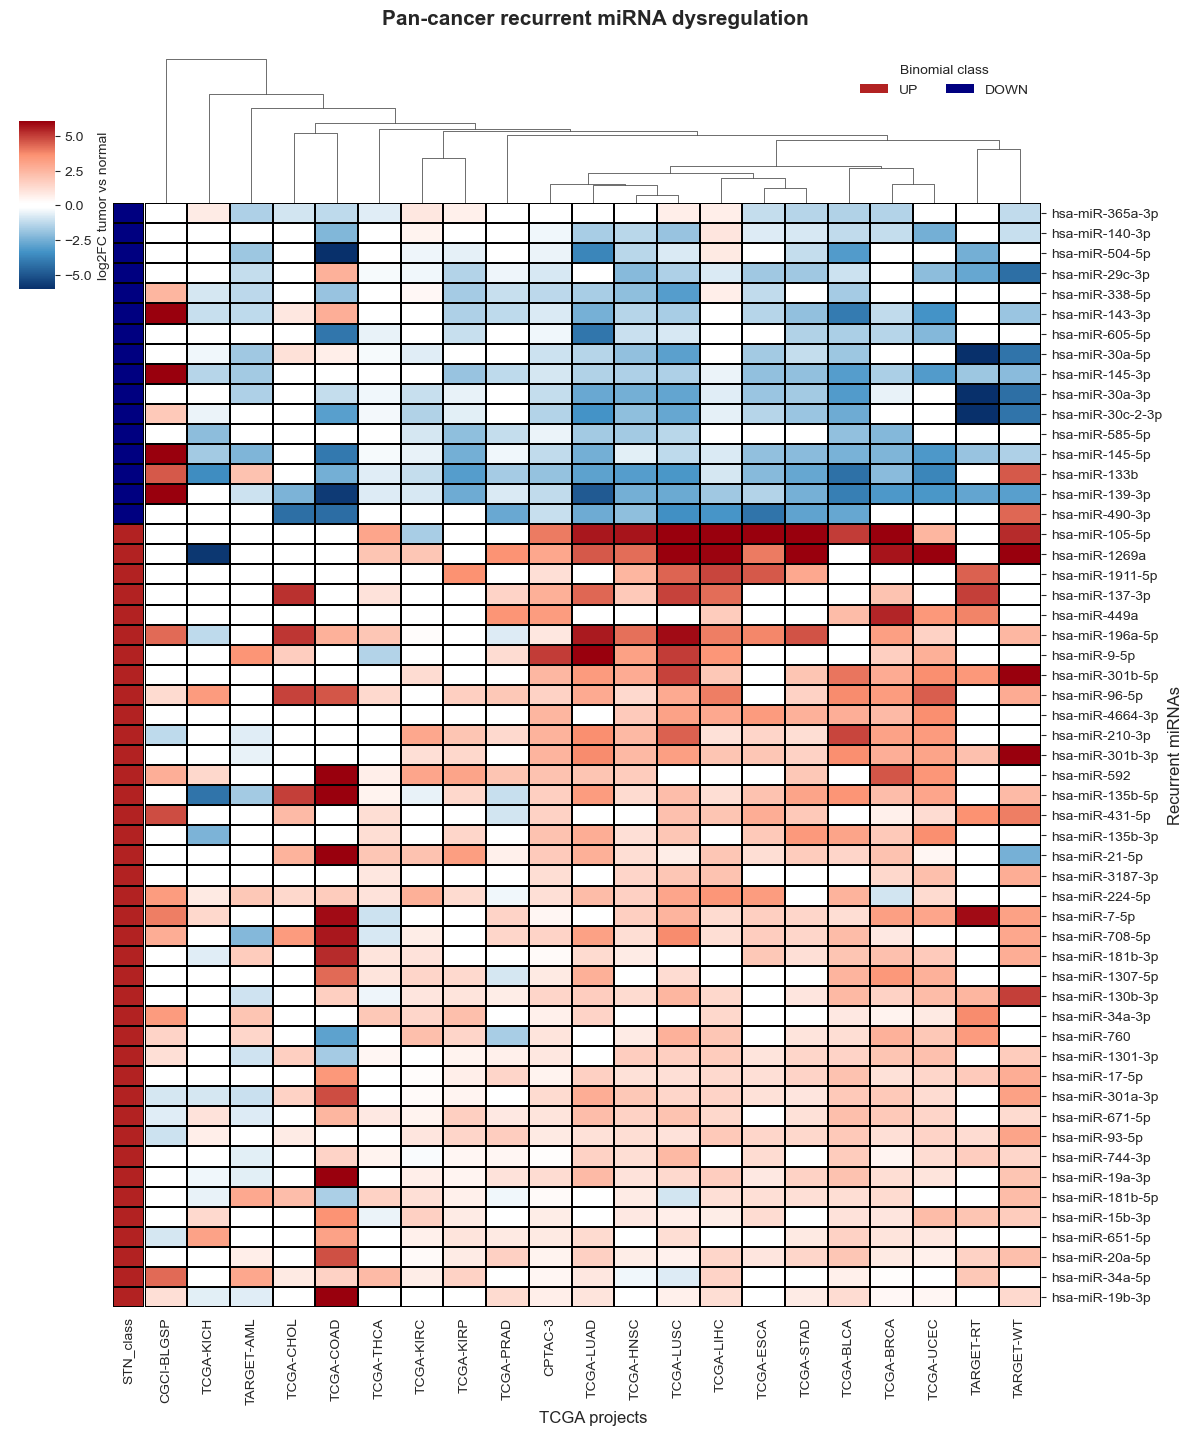

In [290]:
plot_pan_cancer_clustermap(
    fc_mat,
    row_colors,
    save_pdf="/Users/neuropromotion/Desktop/miRNA/bulk_review/pipeline_python/figures/DE_heatmap.pdf"
)

In [256]:
import matplotlib.pyplot as plt


STN_COLORS = {
    "UPREGULATED":"firebrick",
    "DOWNREGULATED":"navy",
    "NOT_SIGNIFICANT":"lightgray"
}


def plot_stn_donut(
    df,
    class_col="STN_class",
    save_pdf=None
):

    counts = (
        df[class_col]
        .value_counts()
        .reindex([
            "UPREGULATED",
            "DOWNREGULATED",
            "NOT_SIGNIFICANT"
        ])
        .fillna(0)
    )

    labels = [
        "Upregulated",
        "Downregulated",
        "Non-significant"
    ]

    colors = [
        STN_COLORS[k]
        for k in counts.index
    ]

    total = counts.sum()

    fig,ax = plt.subplots(
        figsize=(7,7),
        dpi=300
    )

    wedges,texts,autotexts = ax.pie(
    counts.values,
    colors=colors,
    startangle=90,

    wedgeprops=dict(
        width=0.42,
        edgecolor="white",
        linewidth=1
    ),

    autopct=lambda p:
        f"{p:.1f}%"
        if p>3 else "",

    pctdistance=1.1  # <-- ключевой параметр
)



    ###################################
    # center text
    ###################################

    ax.text(
        0,0,
        f"{total}\nmiRNAs",
        ha="center",
        va="center",
        fontsize=18,
        fontweight="bold"
    )


    ###################################
    # legend with n
    ###################################

    leg_labels = [
        f"{lab} (n={n})"
        for lab,n in zip(
            labels,
            counts.values
        )
    ]

    ax.legend(
        wedges,
        leg_labels,
        loc="center left",
        bbox_to_anchor=(1.02,0.5),
        frameon=False
    )

    ax.set_title(
        "Pan-cancer recurrent dysregulation",
        fontsize=14,
        fontweight="bold"
    )

    plt.tight_layout()

    if save_pdf:
        plt.savefig(
            save_pdf,
            bbox_inches="tight"
        )

    plt.show()

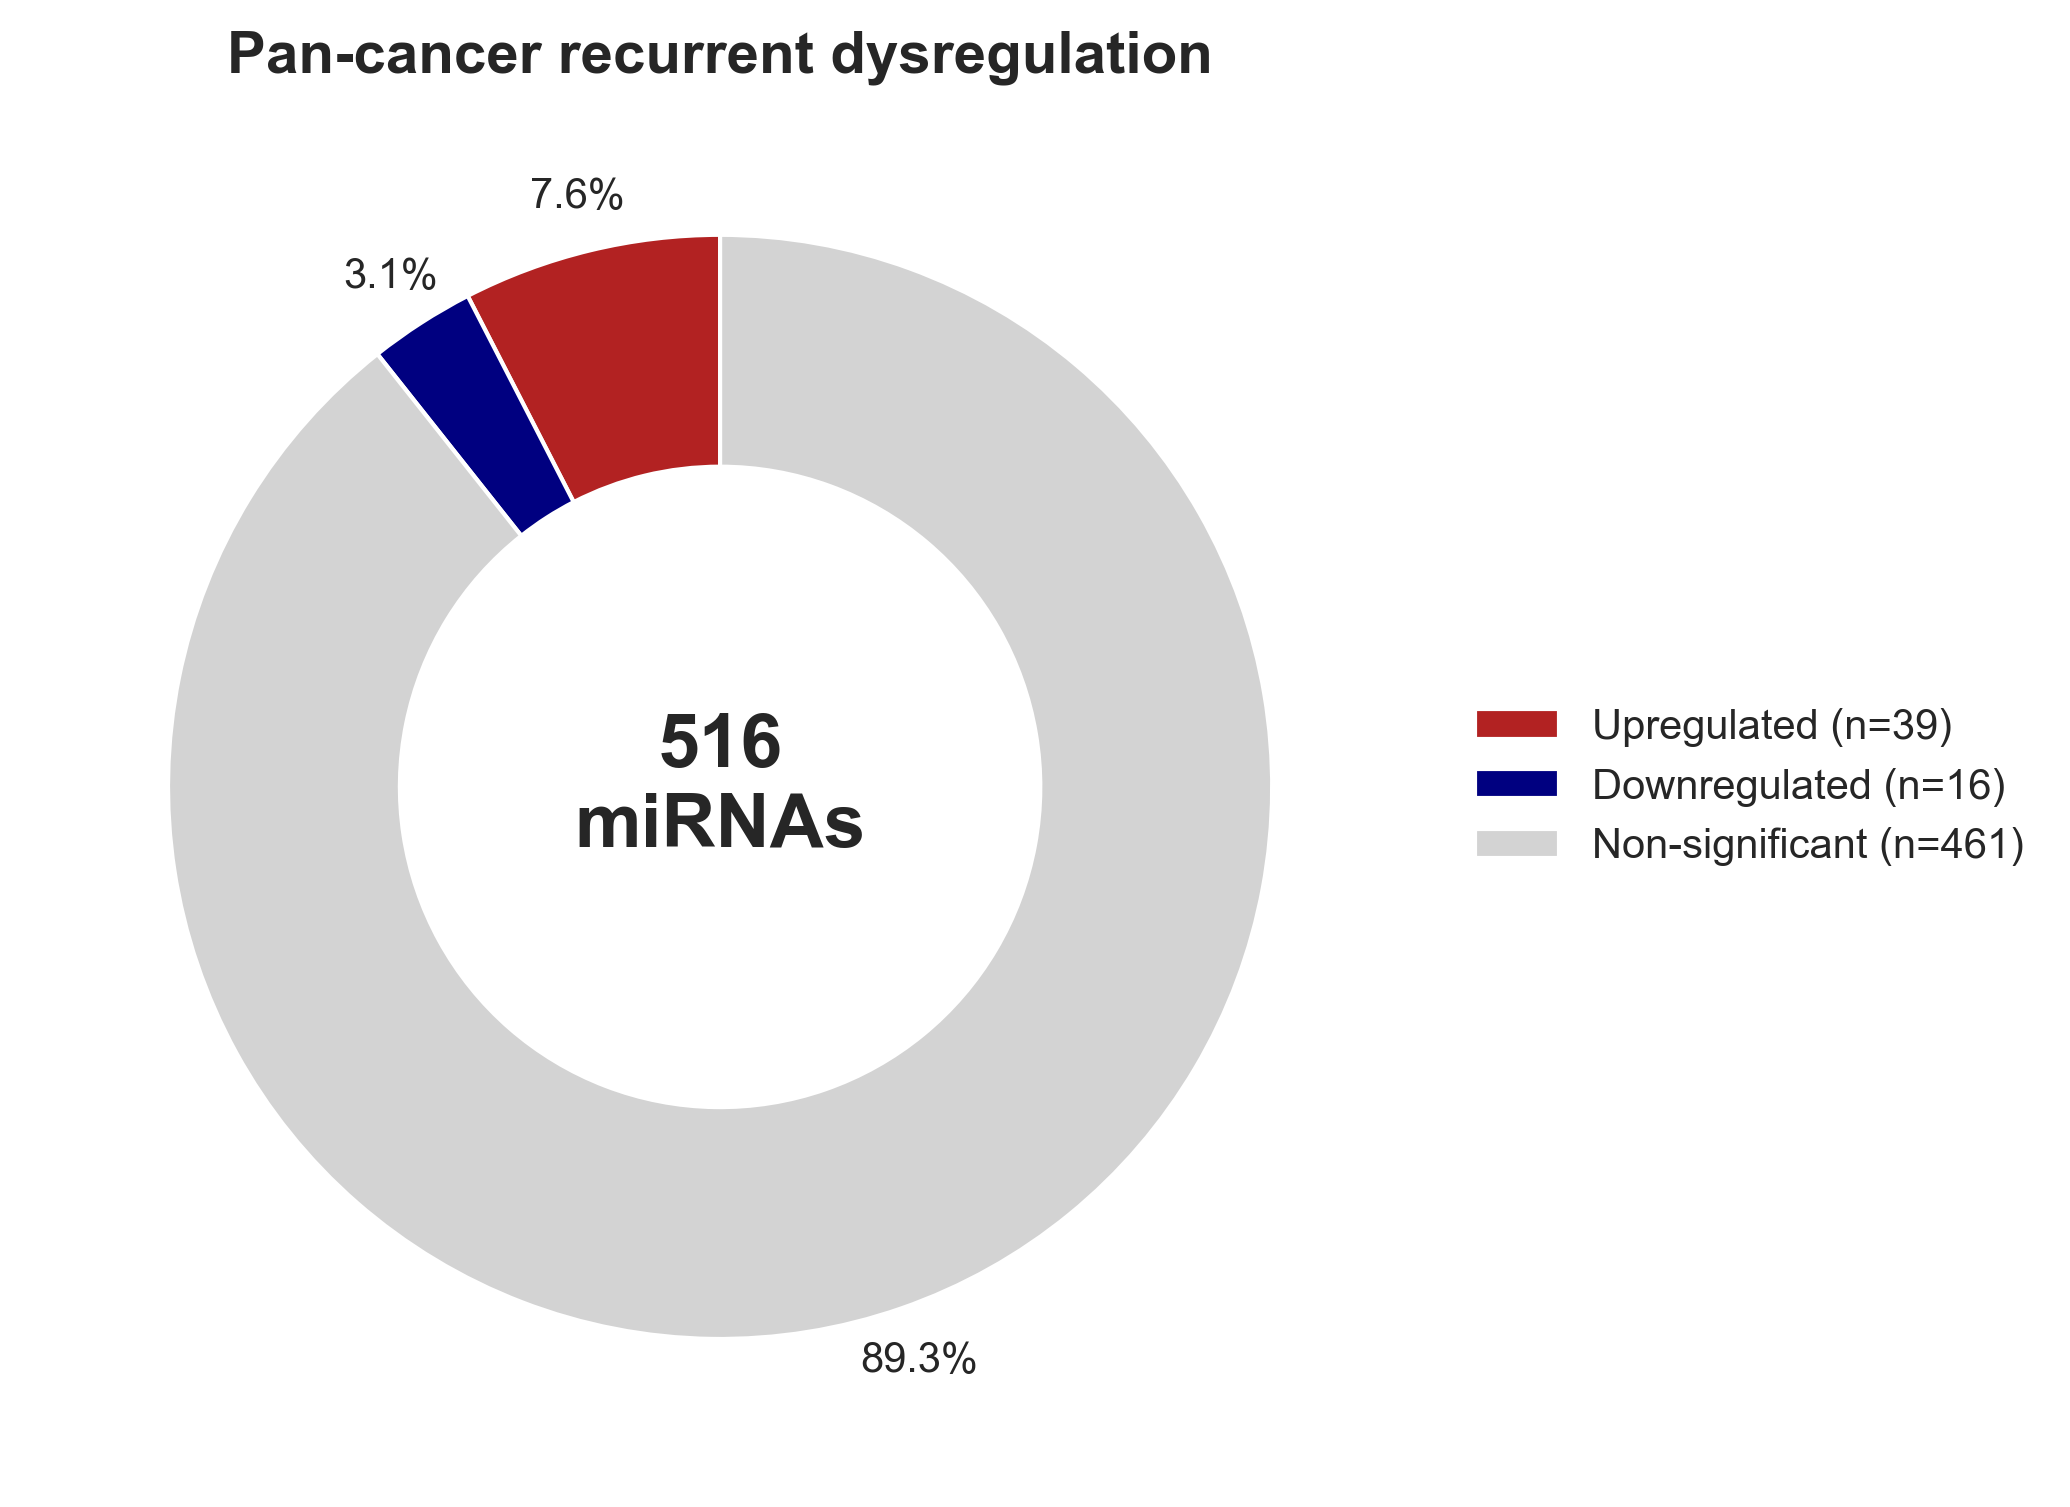

In [257]:
plot_stn_donut(
    merged,
    save_pdf="/Users/neuropromotion/Desktop/miRNA/bulk_review/pipeline_python/figures/STN_donut.pdf"
)

In [270]:
import numpy as np
import matplotlib.pyplot as plt


COLOR_MAP = {
    "UPREGULATED": "firebrick",
    "DOWNREGULATED": "navy",
    "NOT_SIGNIFICANT": "lightgray"
}


def plot_binomial_gradient(
    df,
    save_pdf=None
):

    d = df.copy()

    ########################################
    # binomial significance strength
    ########################################

    d["logp_up"] = -np.log10(d["binom_p_up"].replace(0, np.nan))
    d["logp_down"] = -np.log10(d["binom_p_down"].replace(0, np.nan))

    d["strength"] = d[["logp_up","logp_down"]].max(axis=1)

    ########################################
    # continuous recurrence score
    ########################################

    d["score"] = (
        d["n_projects_up"].fillna(0)
        - d["n_projects_down"].fillna(0)
    )

    ########################################
    # ranking by statistical strength
    ########################################

    d = d.sort_values(
        "strength",
        ascending=False
    ).reset_index(drop=True)

    d["x"] = np.arange(len(d))

    ########################################
    # plot
    ########################################

    fig, ax = plt.subplots(
        figsize=(14,6),
        dpi=300
    )

    colors = d["STN_class"].map(COLOR_MAP)

    ax.scatter(
        d["x"],
        d["score"],

        s=25 + d["strength"] * 6,

        c=colors,
        alpha=0.85,

        edgecolor="black",
        linewidth=0.25
    )

    ########################################
    # zero reference line
    ########################################

    ax.axhline(0, color="black", lw=1, alpha=0.6)

    ########################################
    # TOP 5 UP + TOP 5 DOWN labels
    ########################################

    top_up = d.nlargest(5, "score")
    top_down = d.nsmallest(5, "score")

    to_label = pd.concat([top_up, top_down])

    for _, r in to_label.iterrows():

        ax.text(
            r["x"],
            r["score"],

            r["mature_name"],

            fontsize=8,

            rotation=45,

            ha="right",

            va="bottom" if r["score"] > 0 else "top",

            bbox=dict(
                facecolor="white",
                alpha=0.6,
                edgecolor="none",
                pad=1
            )
        )

    ########################################
    # axes
    ########################################

    ax.set_xlabel(
        "miRNAs (ranked by binomial strength)",
        fontsize=12
    )

    ax.set_ylabel(
        "Recurrent dysregulation score\n(#UP projects - #DOWN projects)",
        fontsize=12
    )

    ax.set_title(
        "Pan-cancer miRNA dysregulation landscape",
        fontsize=14,
        fontweight="bold"
    )

    ax.set_xticks([])

    ########################################
    # legend
    ########################################

    for k, v in COLOR_MAP.items():
        ax.scatter([], [], c=v, label=k)

    ax.legend(frameon=False, title="Class")

    plt.tight_layout()

    if save_pdf:
        plt.savefig(save_pdf, bbox_inches="tight")

    plt.show()

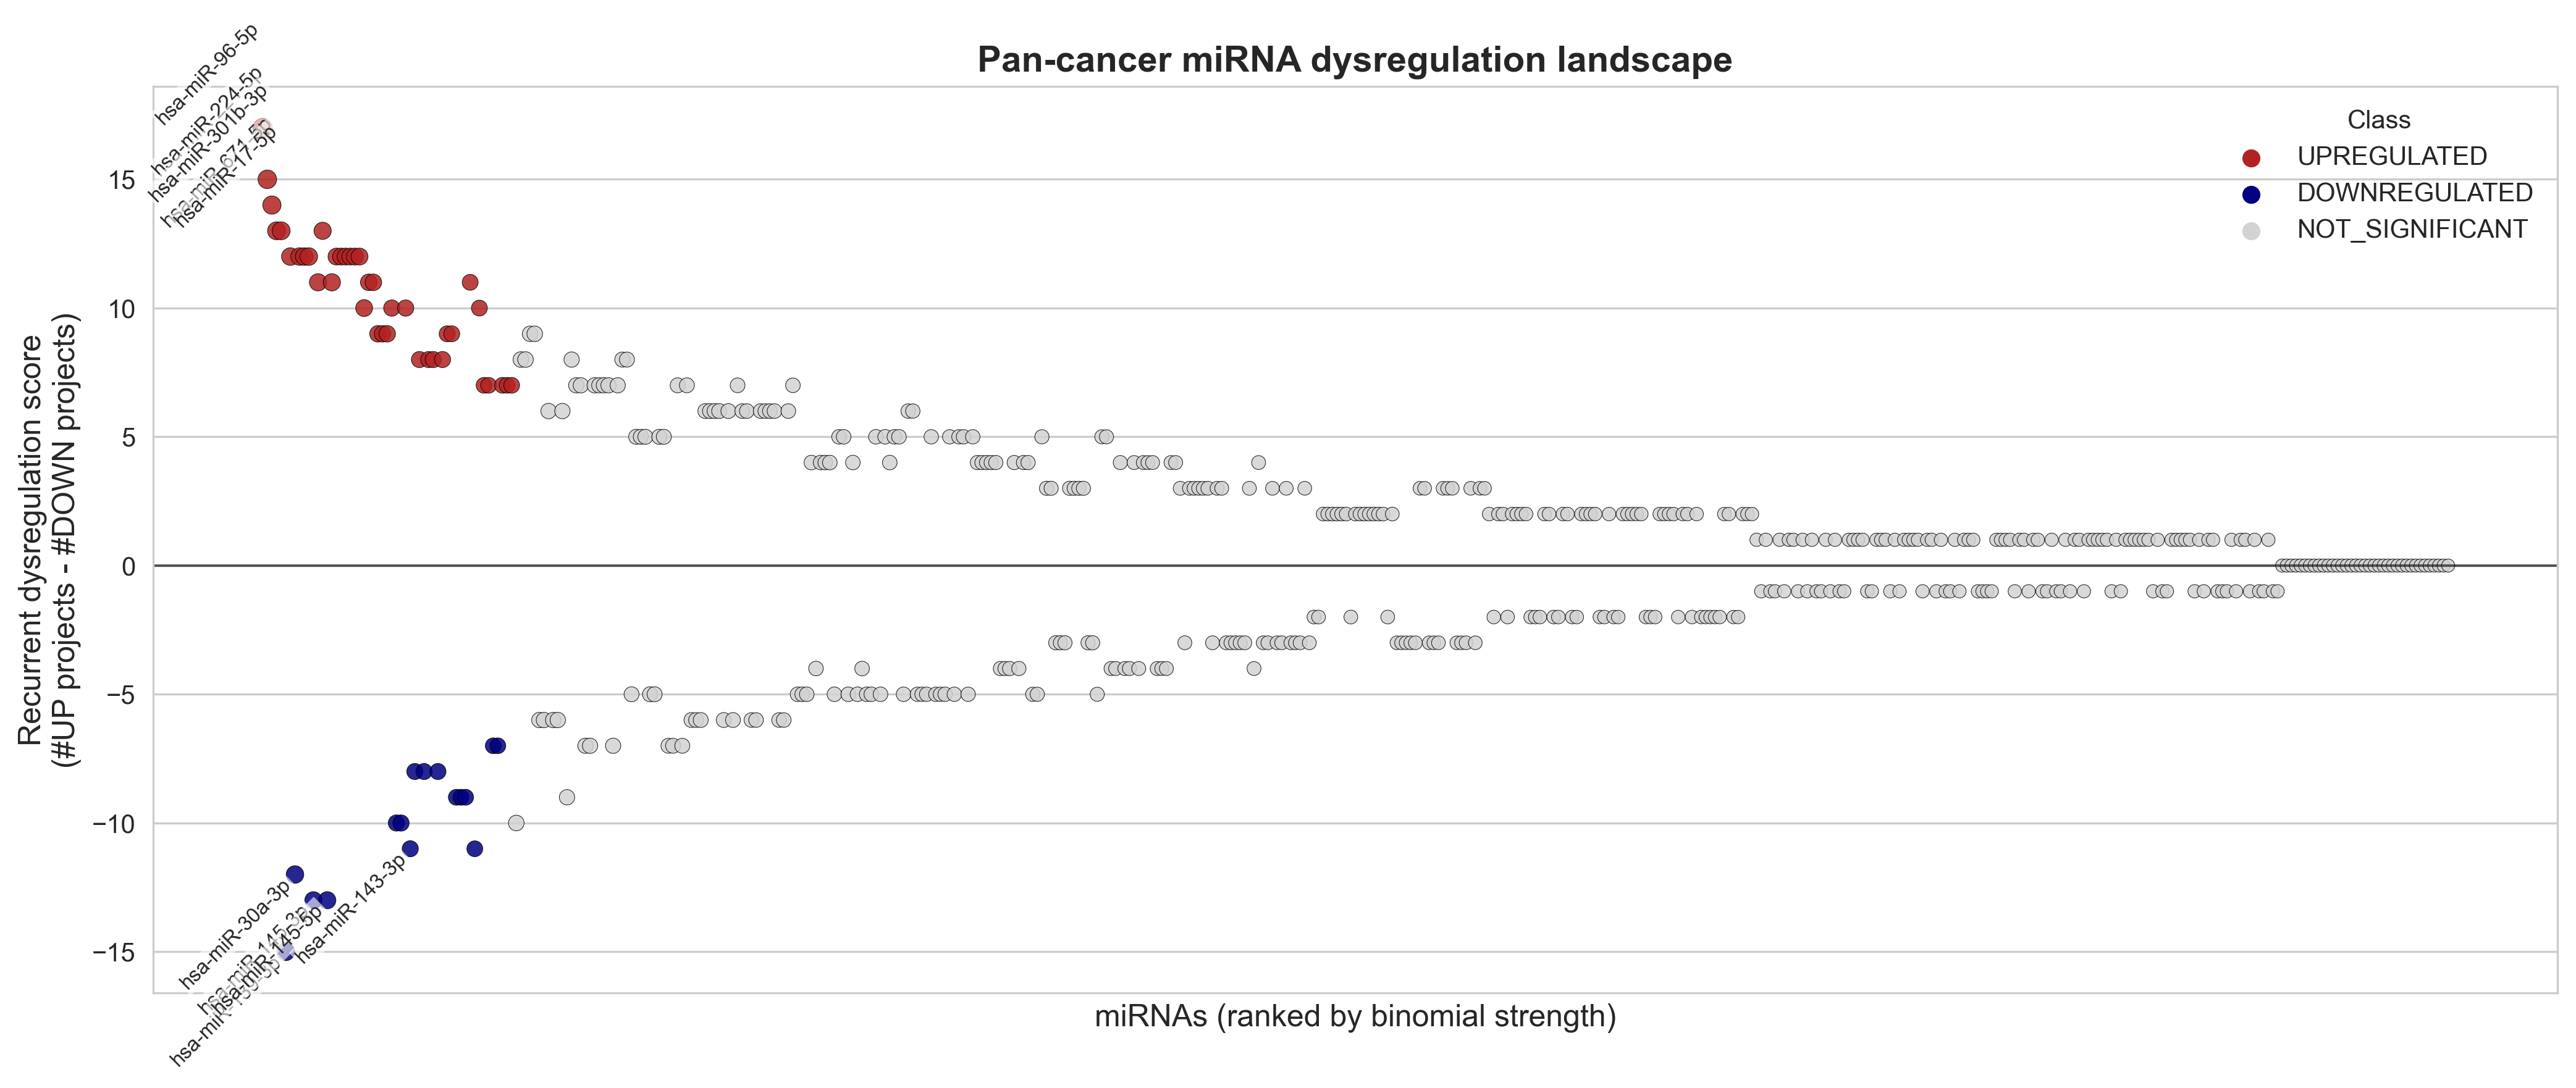

In [ ]:
plot_binomial_gradient(
    merged,
    save_pdf = '/Users/neuropromotion/Desktop/miRNA/bulk_review/pipeline_python/figures/logfc_grad_SNT.pdf'
)